<h1 align="center"><b>Лабораторна робота №2</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

In [3]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
print("Setup complete")

Setup complete


### Завдання №1
Аналіз чутливості параметрів.

Провести чутливий аналіз моделей. Для кожної моделі змінювати значення параметрів та проаналізувати, як ці зміни впливають на результат.

**Мета:** виявити критичні параметри, при зміні яких система демострує значні відхилення від базових прогнозів. 

#### Модель Мальтуса
$$
\frac{dy}{dt} = ky
$$

$$
y(t) = y_0 e^{kt}
$$

In [4]:
def maltus_model(y0: float, k: float, t: np.ndarray) -> np.ndarray:
    return y0 * np.exp(k * t)

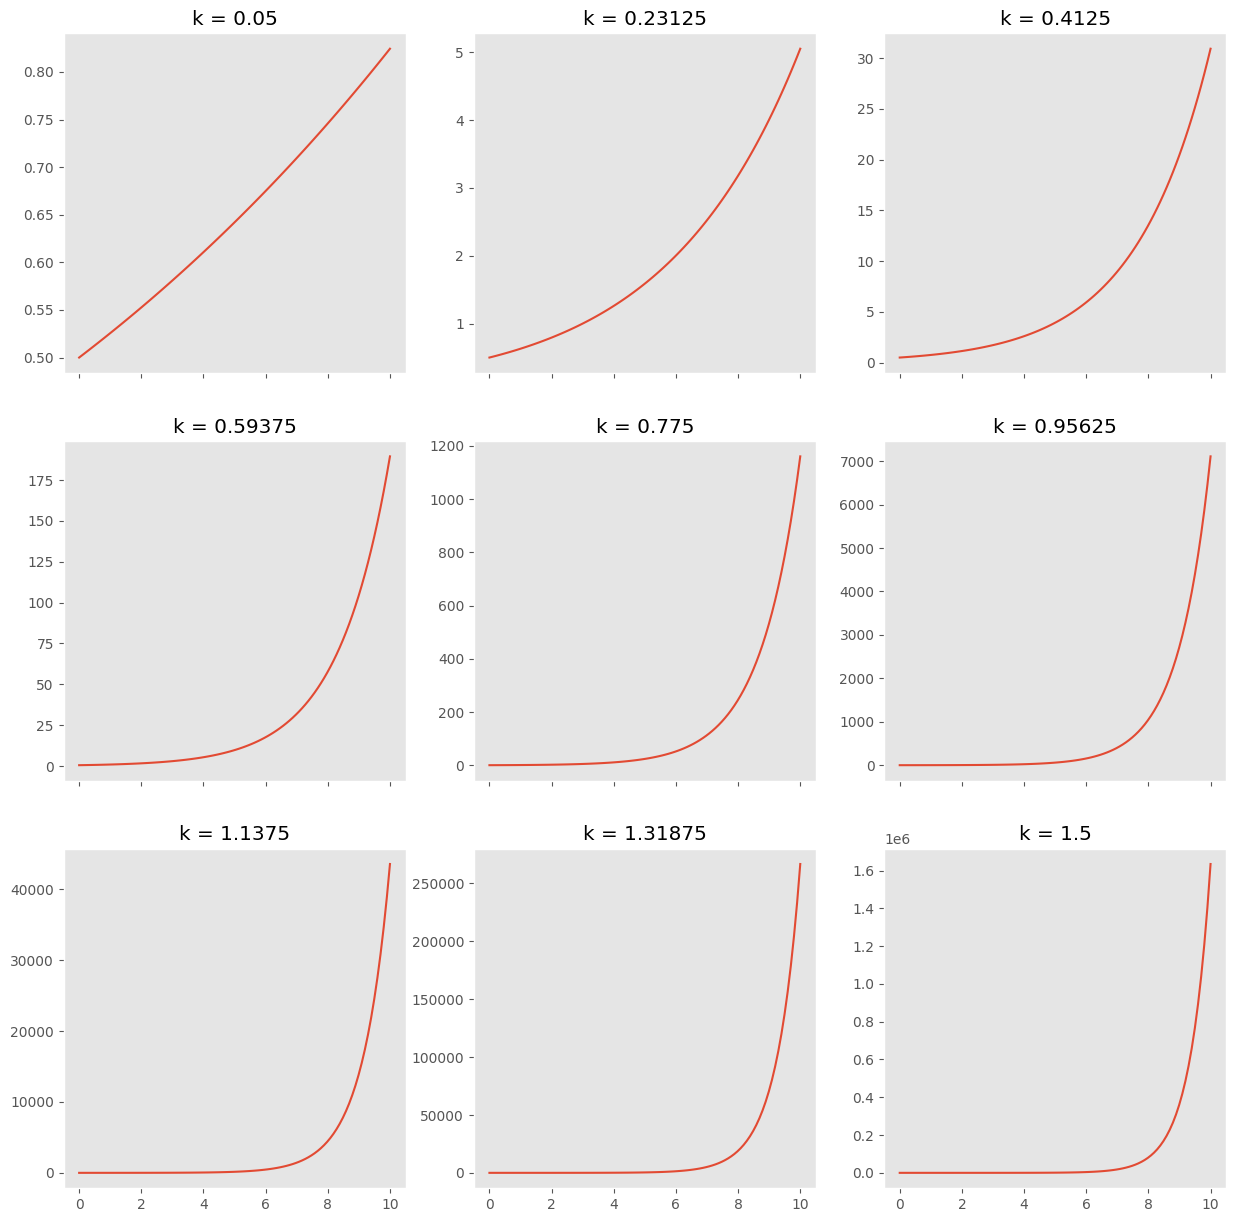

In [5]:
y0 = 0.5
k = np.linspace(0.05, 1.5, 9)
t = np.linspace(0, 10, 100)

fig, axs = plt.subplots(3, 3, figsize= (15, 15), sharex=True)

for i in range(len(k)):
    axs[i//3][i%3].plot(t, maltus_model(y0, k[i], t))
    axs[i//3][i%3].set_title(f"k = {k[i]}")
    axs[i//3][i%3].grid()

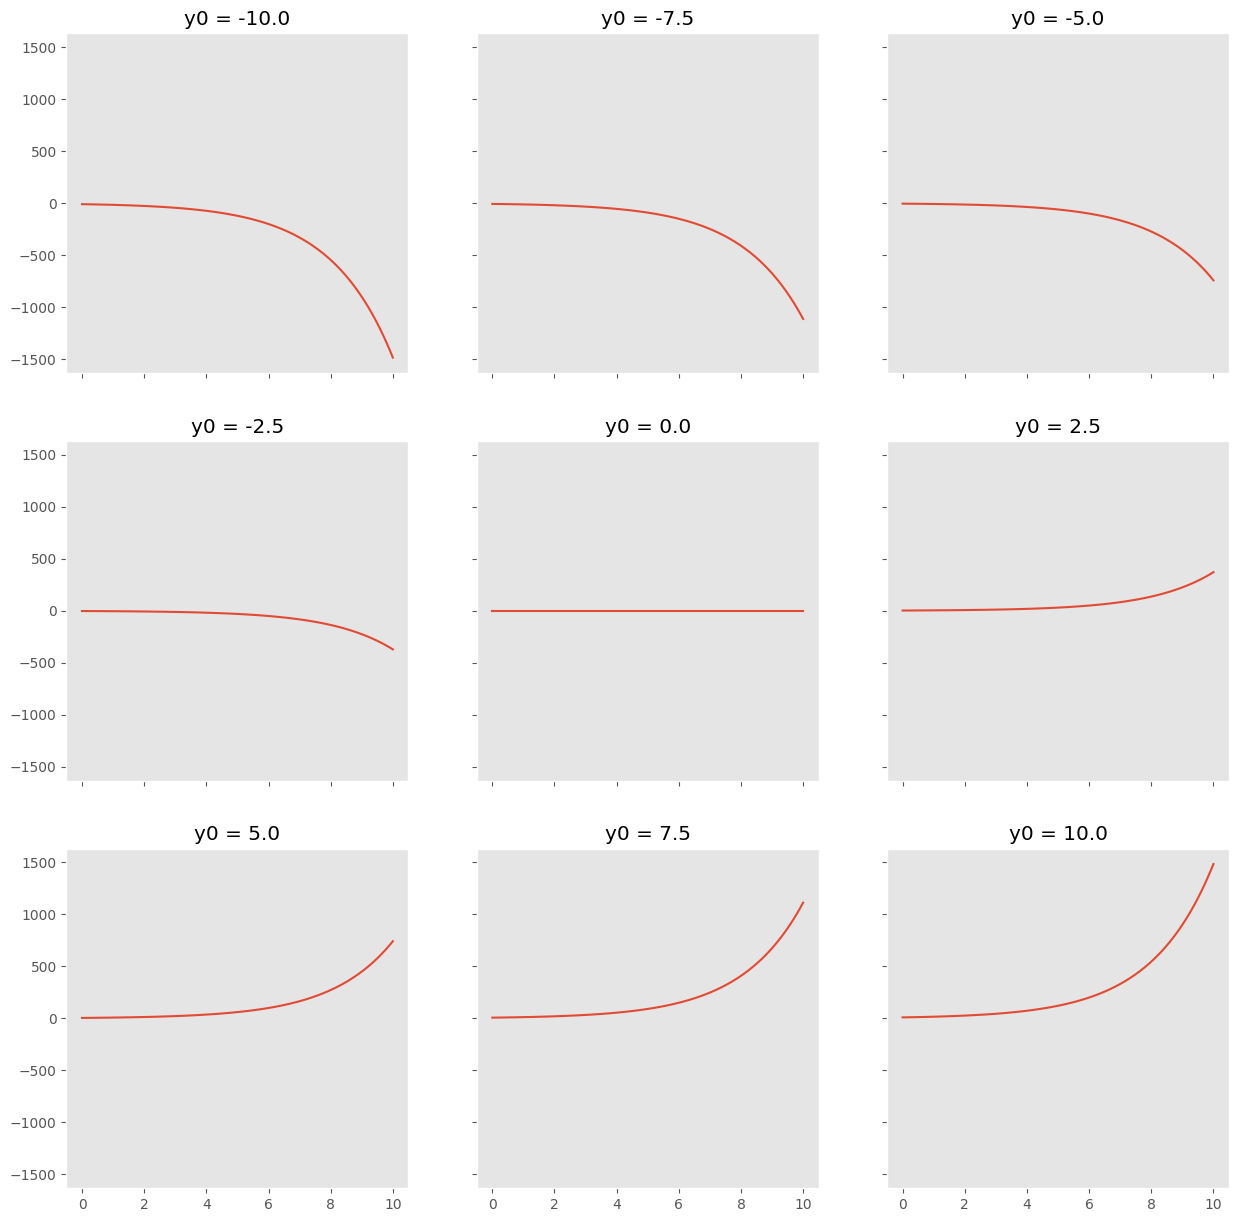

In [6]:
k = 0.5
y0 = np.linspace(-10, 10, 9)
t = np.linspace(0, 10, 100)

fig, axs = plt.subplots(3, 3, figsize= (15, 15), sharex=True, sharey=True)

for i in range(len(y0)):
    axs[i//3][i%3].plot(t, maltus_model(y0[i], k, t))
    axs[i//3][i%3].set_title(f"y0 = {y0[i]}")
    axs[i//3][i%3].grid()

#### Логістична модель
$$
\frac{dy}{dt} = ry \left( 1 - \frac{y}{K} \right), \quad y(0) = y_0;
$$

$$
y(t) = \frac{K}{1 + \left( \frac{K - y_0}{y_0} \right) e^{-rt}}
$$

* $r$ — швидкість зростання популяції,
* $K$ — максимальна місткість середовища (стаціонарне значення популяції),
* $y_0$ — початкове значення популяції.

In [7]:
def logistic_model(r: float, K: float, y0: float, t: np.ndarray) -> np.ndarray:
    return K / (1 + ((K - y0) / y0) * np.exp(-r * t))

100


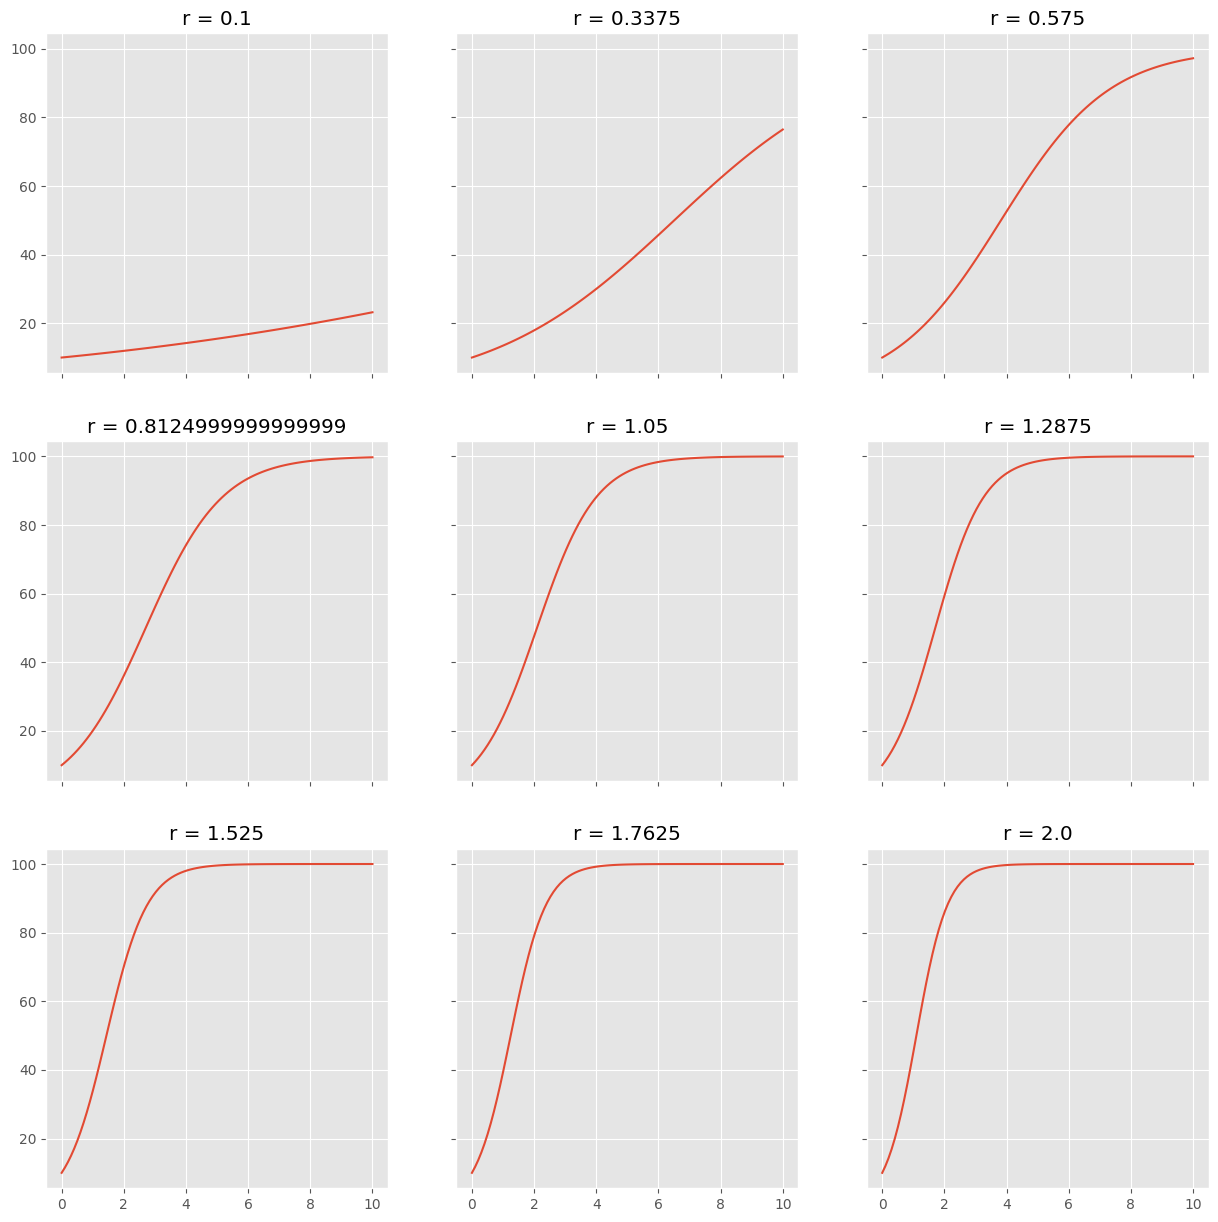

In [59]:
r = np.linspace(0.1, 2, 9)
K = 100
y0 = 10
t = np.linspace(0, 10, 100)

print(len(logistic_model(r[0], K, y0, t)))

fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

for i in range(len(r)):
    axs[i//3][i%3].plot(t, logistic_model(r[i], K, y0, t))
    axs[i//3][i%3].set_title(f"r = {r[i]}")

100


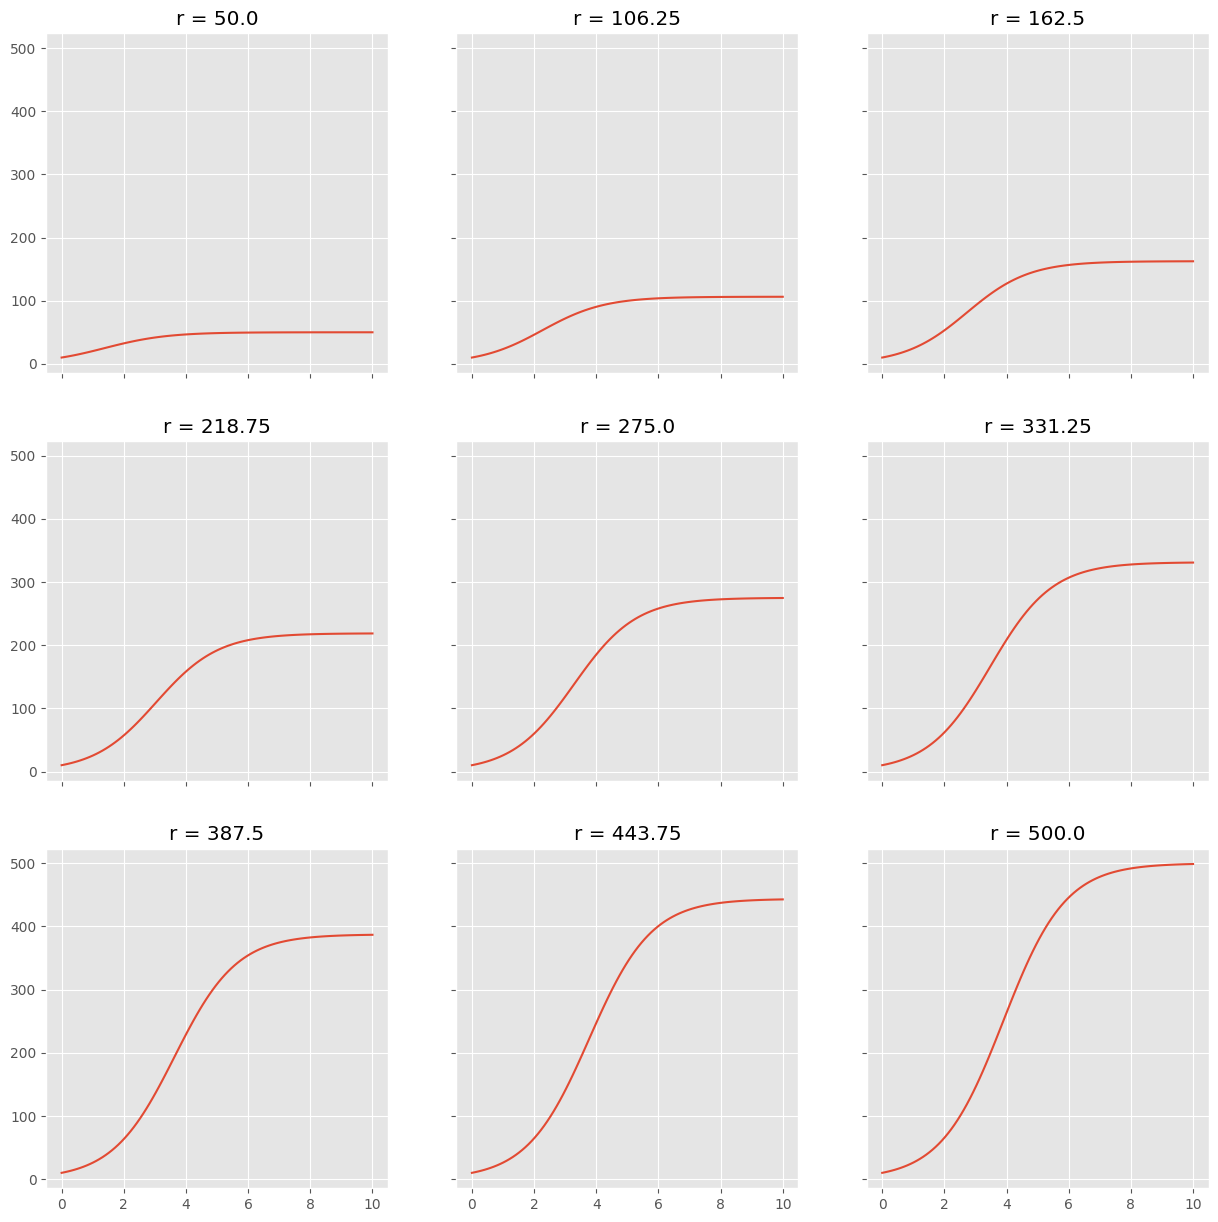

In [60]:
r = 1
K = np.linspace(50, 500, 9)
y0 = 10
t = np.linspace(0, 10, 100)

print(len(logistic_model(r, K[i], y0, t)))

fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

for i in range(len(K)):
    axs[i//3][i%3].plot(t, logistic_model(r, K[i], y0, t))
    axs[i//3][i%3].set_title(f"r = {K[i]}")

100


C:\Users\berku\AppData\Local\Temp\ipykernel_20588\1821329619.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return K / (1 + ((K - y0) / y0) * np.exp(-r * t))


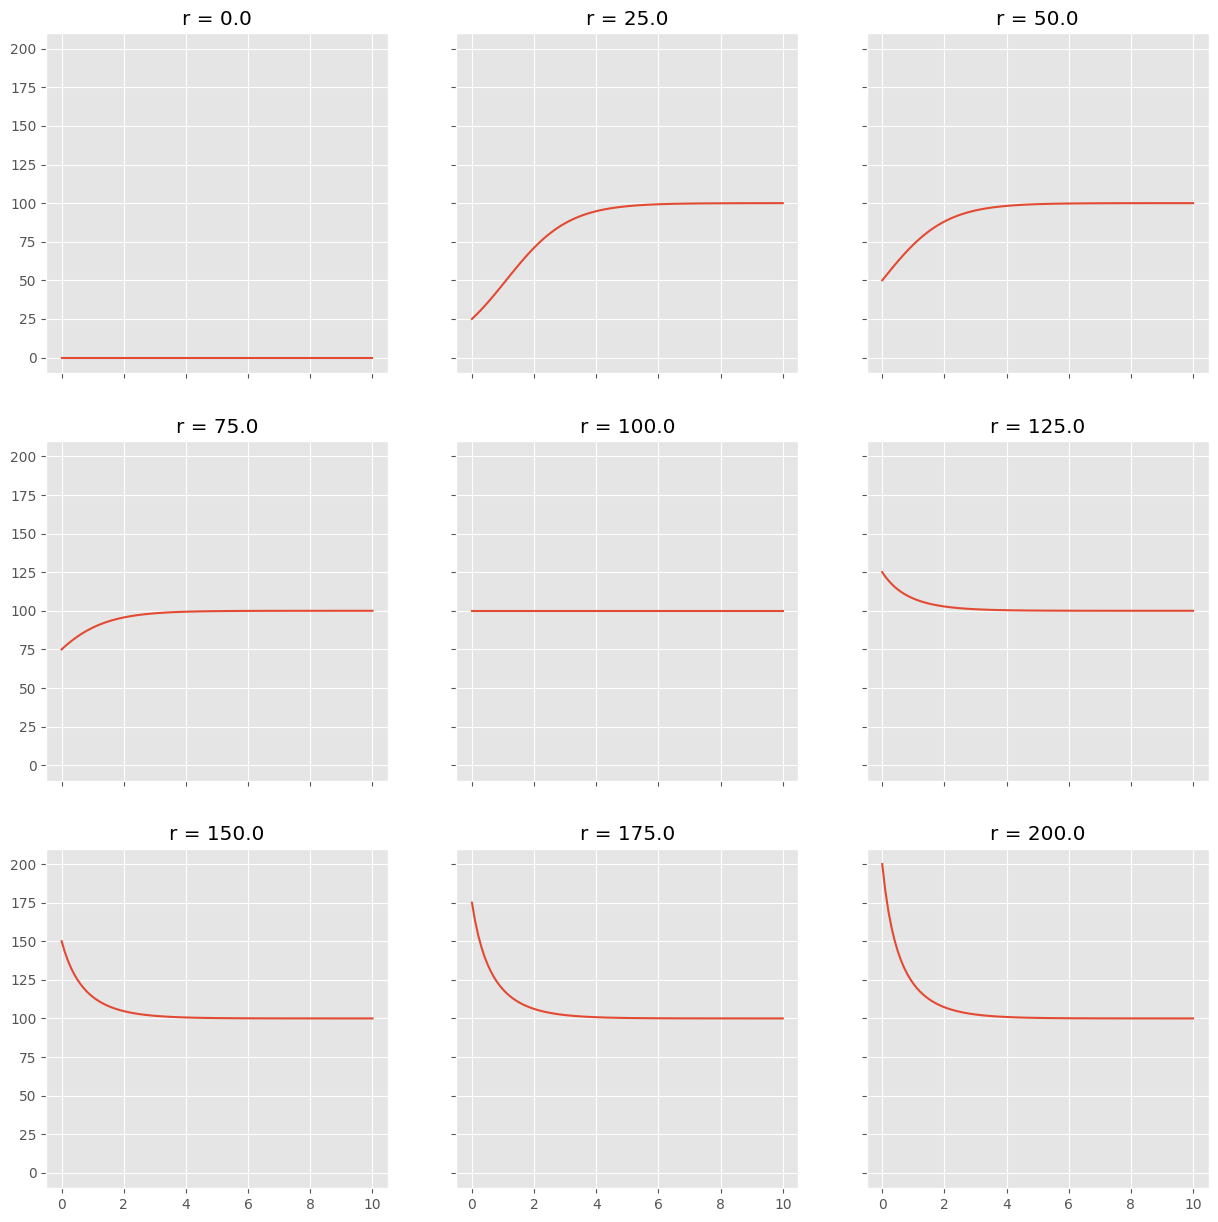

In [61]:
r = 1
K = 100
y0 = np.linspace(0, 200, 9)
t = np.linspace(0, 10, 100)

print(len(logistic_model(r, K, y0[i], t)))

fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

for i in range(len(y0)):
    axs[i//3][i%3].plot(t, logistic_model(r, K, y0[i], t))
    axs[i//3][i%3].set_title(f"r = {y0[i]}")

#### Модель Лотка-Вольтера

$$
\frac{dx}{dt} = \alpha x - \beta x y,
$$

$$
\frac{dy}{dt} = \delta x y - \gamma y,
$$

де

- $\alpha$ — коеф. природного зростання жертв (при відсутності хижаків);
- $\beta$ — коеф. що характеризує зменшення популяції жертв через хижацтво;
- $\delta$ — коеф. приросту хижаків за рахунок споживання жертв;
- $\gamma$ — коеф. природної смертності хижаків.


In [11]:
def lotka_volterra_model(t: float, z: np.ndarray) -> np.ndarray:
    x, y = z
    dxdt: float = alpha * x - beta * x * y
    dydt: float = delta * x * y - gamma * y
    return np.array([dxdt, dydt])

In [12]:
t = np.linspace(0, 40, 300)

alphas = np.linspace(0.5, 1.5, 9)
betas = np.linspace(0.01, 0.1, 9)
deltas = np.linspace(.01, .1, 9)
gammas = np.linspace(0.5, 2, 9)

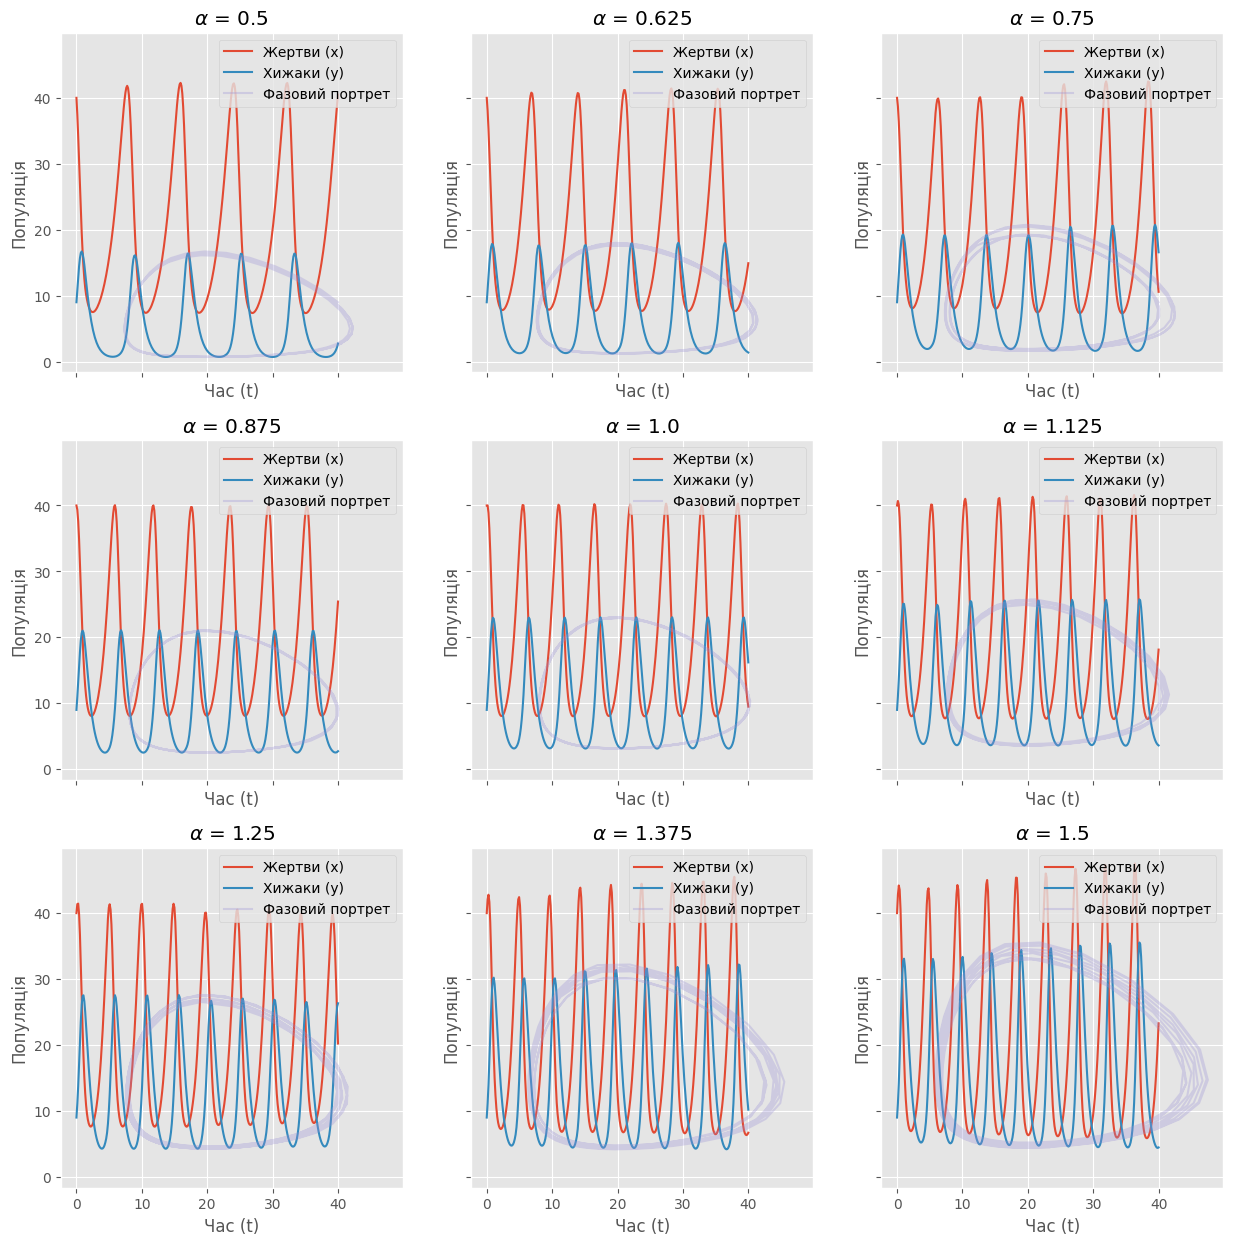

In [13]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

x0 = 40
y0 = 9

beta = 0.1
delta = 0.075
gamma = 1.5

for i in range(9):
    alpha = alphas[i]
    
    solution = solve_ivp(lotka_volterra_model, (0, 40), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label="Жертви (x)")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label="Хижаки (y)")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], label="Фазовий портрет", alpha=0.3)
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\alpha$ = {alpha}")
    axs[i//3][i%3].set_xlabel("Час (t)")
    axs[i//3][i%3].set_ylabel("Популяція")

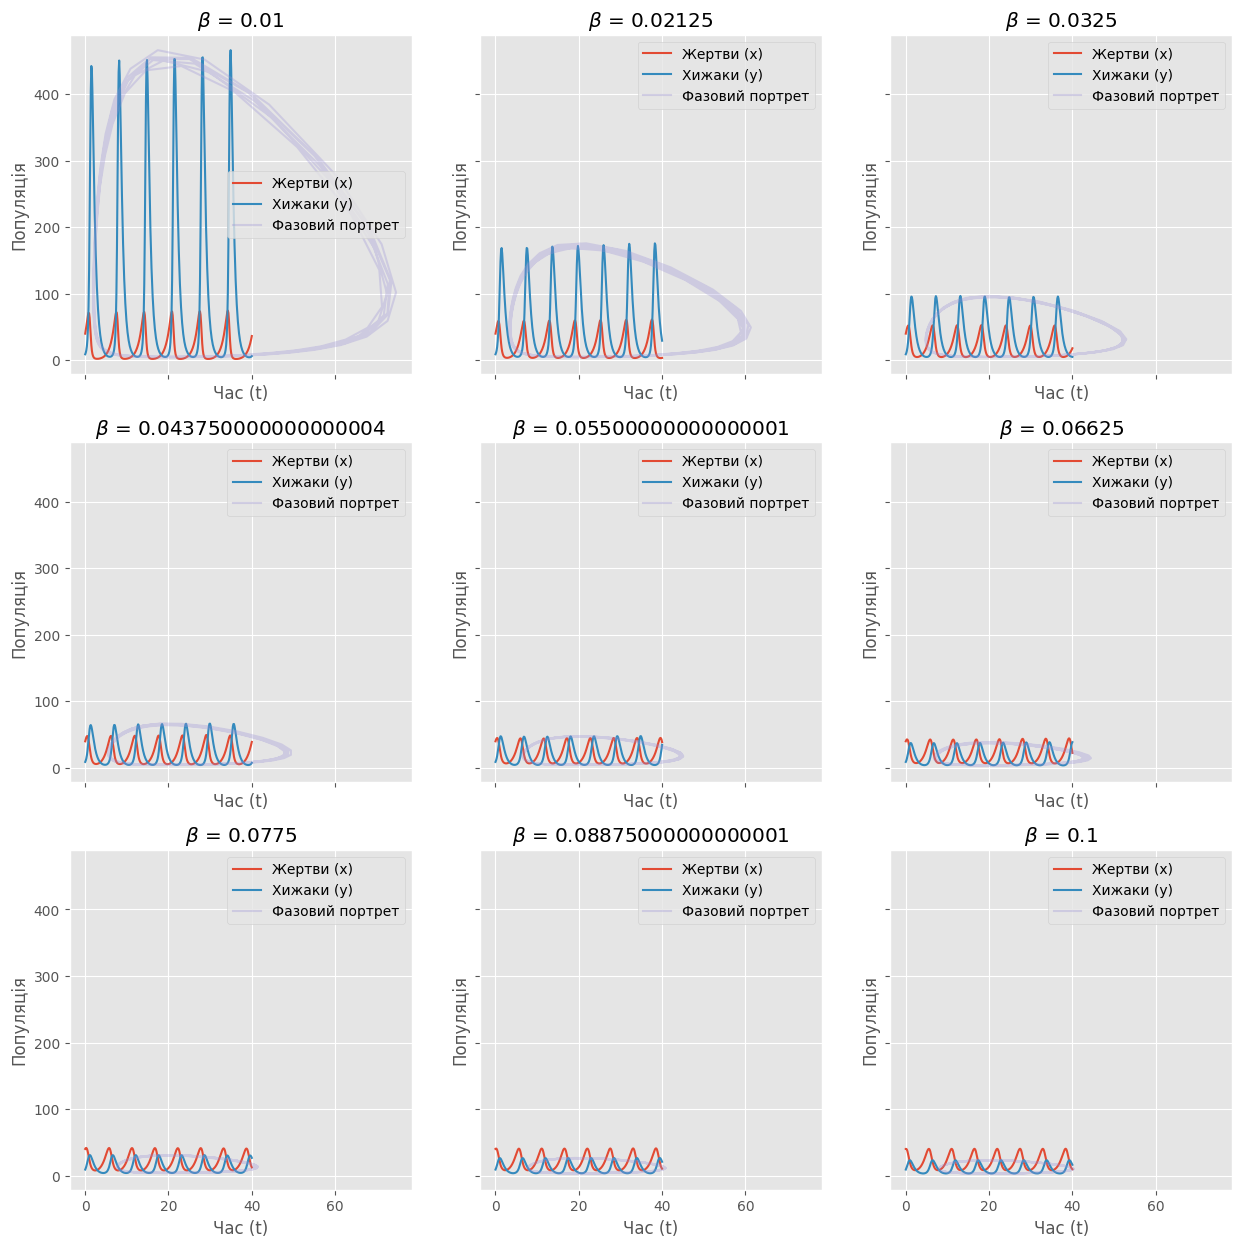

In [14]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

x0 = 40
y0 = 9

alpha = 1
delta = 0.075
gamma = 1.5

for i in range(9):
    beta = betas[i]
    
    solution = solve_ivp(lotka_volterra_model, (0, 40), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label="Жертви (x)")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label="Хижаки (y)")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], label="Фазовий портрет", alpha=0.3)
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\beta$ = {beta}")
    axs[i//3][i%3].set_xlabel("Час (t)")
    axs[i//3][i%3].set_ylabel("Популяція")

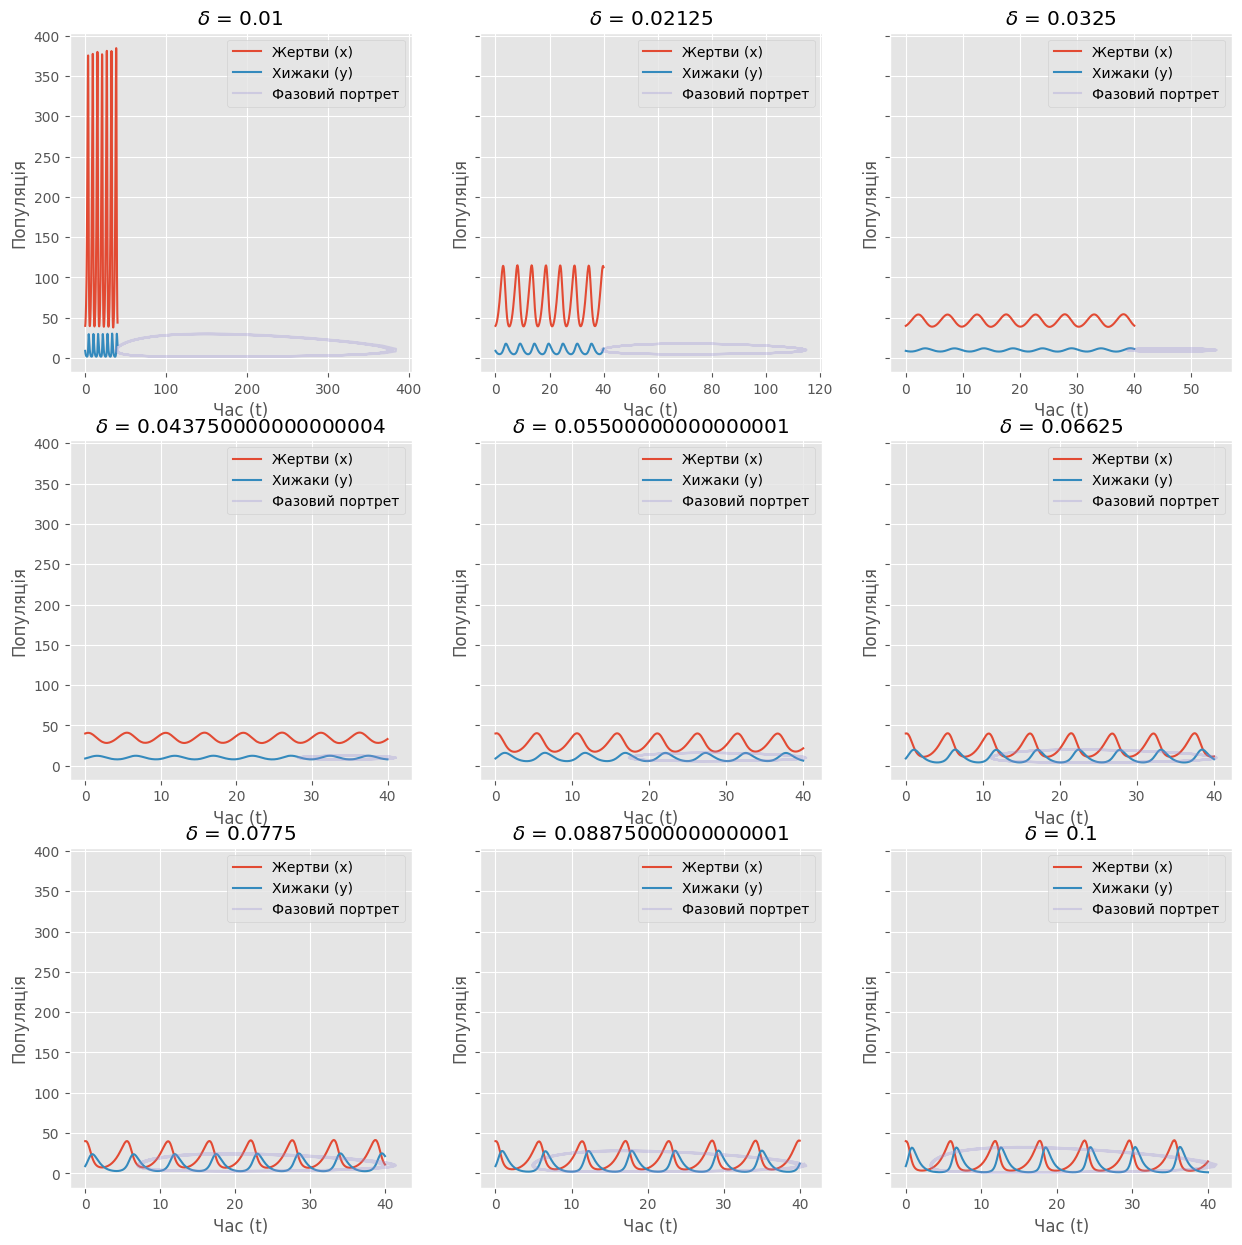

In [15]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharey=True, )

x0 = 40
y0 = 9

alpha = 1
beta = .1
gamma = 1.5

for i in range(9):
    delta = deltas[i]
    
    solution = solve_ivp(lotka_volterra_model, (0, 40), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label="Жертви (x)")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label="Хижаки (y)")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], label="Фазовий портрет", alpha=0.3)
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\delta$ = {delta}")
    axs[i//3][i%3].set_xlabel("Час (t)")
    axs[i//3][i%3].set_ylabel("Популяція")

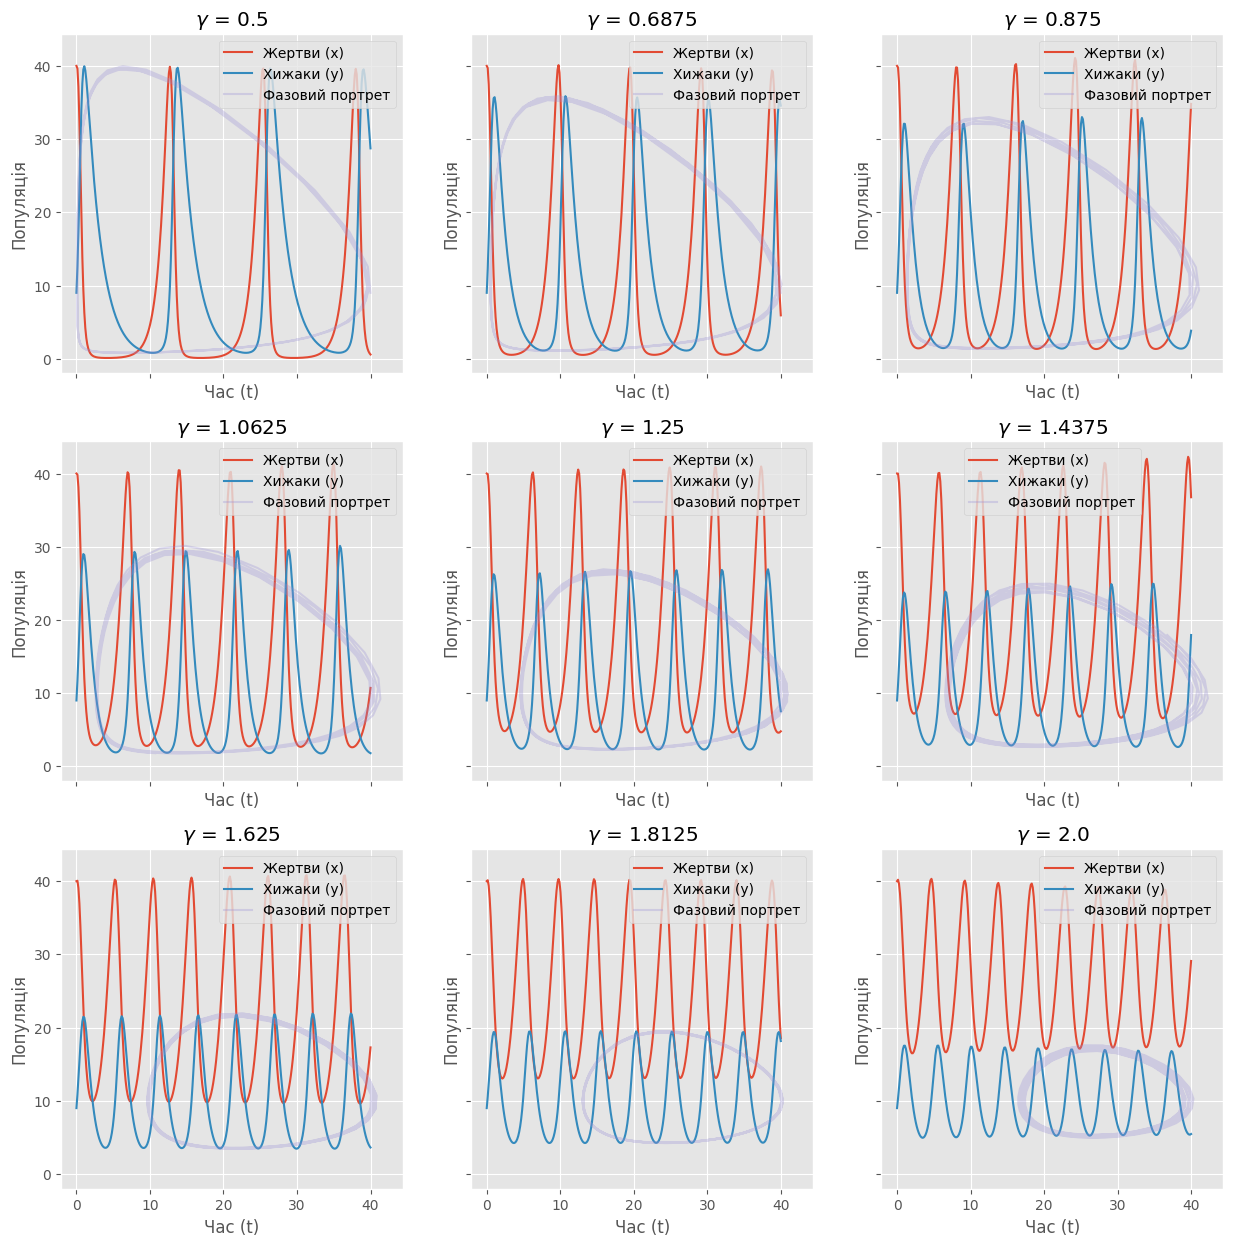

In [16]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

x0 = 40
y0 = 9

alpha = 1
beta = .1
delta = 0.075

for i in range(9):
    gamma = gammas[i]
    
    solution = solve_ivp(lotka_volterra_model, (0, 40), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label="Жертви (x)")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label="Хижаки (y)")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], label="Фазовий портрет", alpha=0.3)
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\gamma$ = {gamma}")
    axs[i//3][i%3].set_xlabel("Час (t)")
    axs[i//3][i%3].set_ylabel("Популяція")

#### Модель EOQ

$$
TC(Q) = \frac{D}{Q}S + \frac{Q}{2}H,
$$

де
* $D$ — щорічний попит є сталим і відомим;
* $S$ — витрати на оформлення замовлення;
* $H$ — вартість зберігання одиниці товару на складі за одиницю на рік.

In [17]:
def compute_eoq(D: float, S: float, H: float) -> float:
    return np.sqrt((2 * D * S) / H)

def total_cost(Q, D: float, S: float, H: float) -> float:
    return (D / Q) * S + (Q / 2) * H

In [18]:
Ds: np.ndarray = np.linspace(500, 5000, 9)
Ss: np.ndarray = np.linspace(10, 200, 9)
Hs: np.ndarray = np.linspace(1, 20, 9)

q = np.linspace(1, 500, 100)

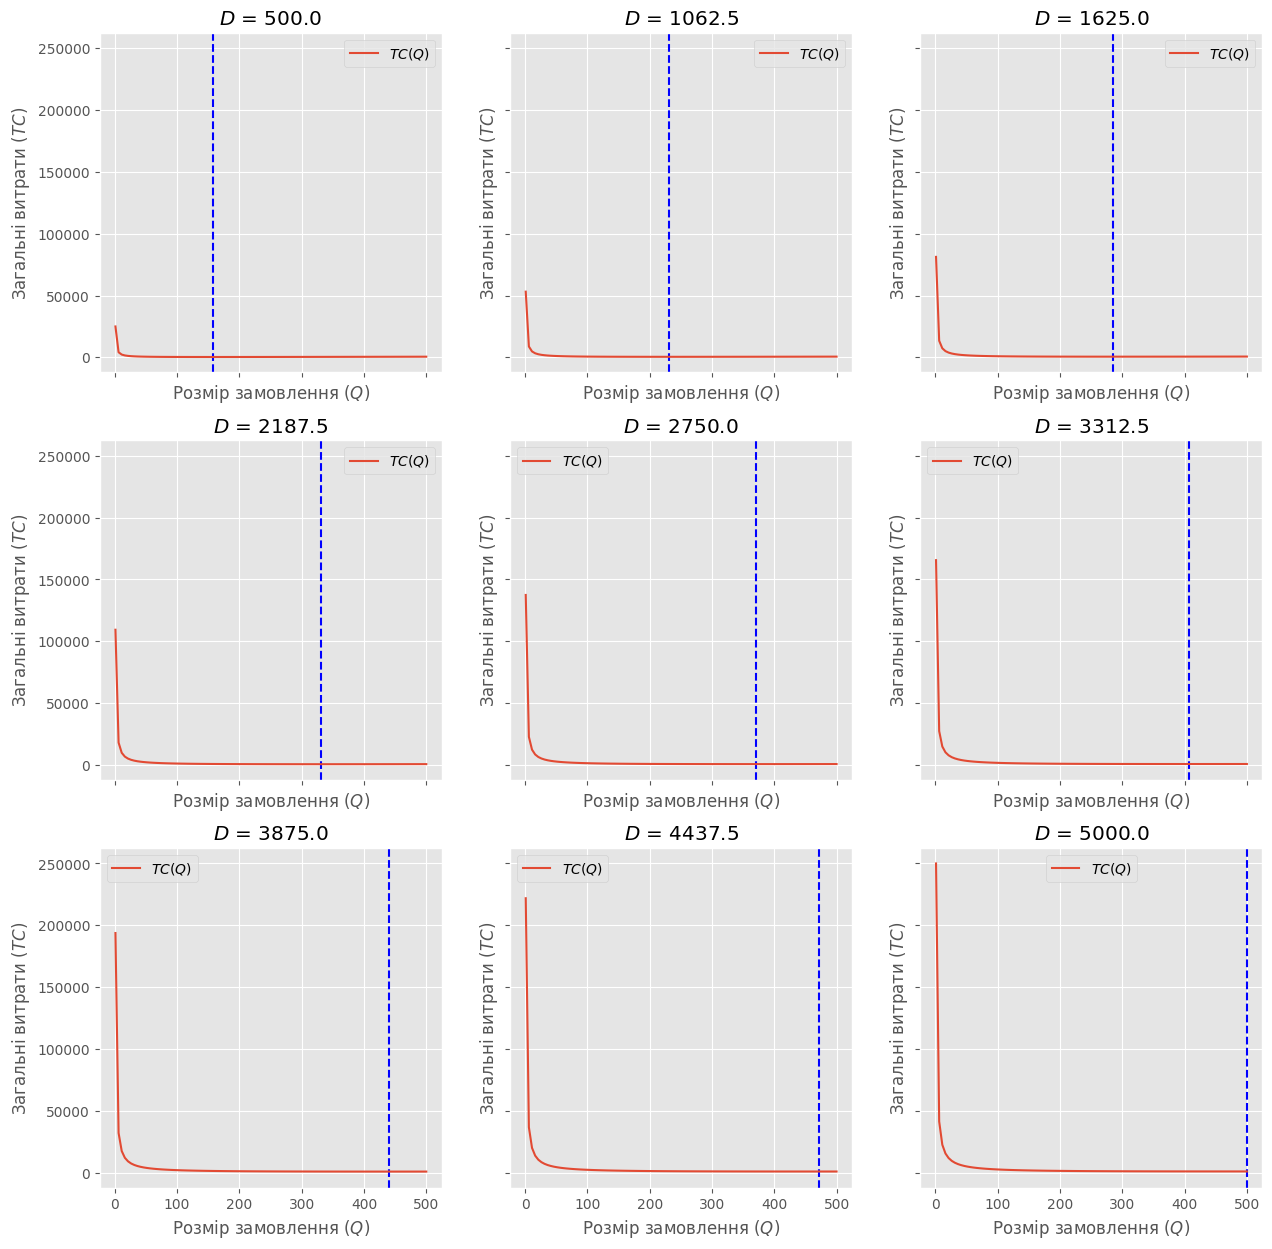

In [19]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

S = 50
H = 2

for i in range(9):
    D = Ds[i]
    
    eoq = compute_eoq(D, S, H)
    axs[i//3][i%3].axvline(x=eoq, color="b", linestyle="--")
    axs[i//3][i%3].plot(q, total_cost(q, D, S, H), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$D$ = {D}")
    axs[i//3][i%3].set_xlabel(r"Розмір замовлення $(Q)$")
    axs[i//3][i%3].set_ylabel(r"Загальні витрати $(TC)$")

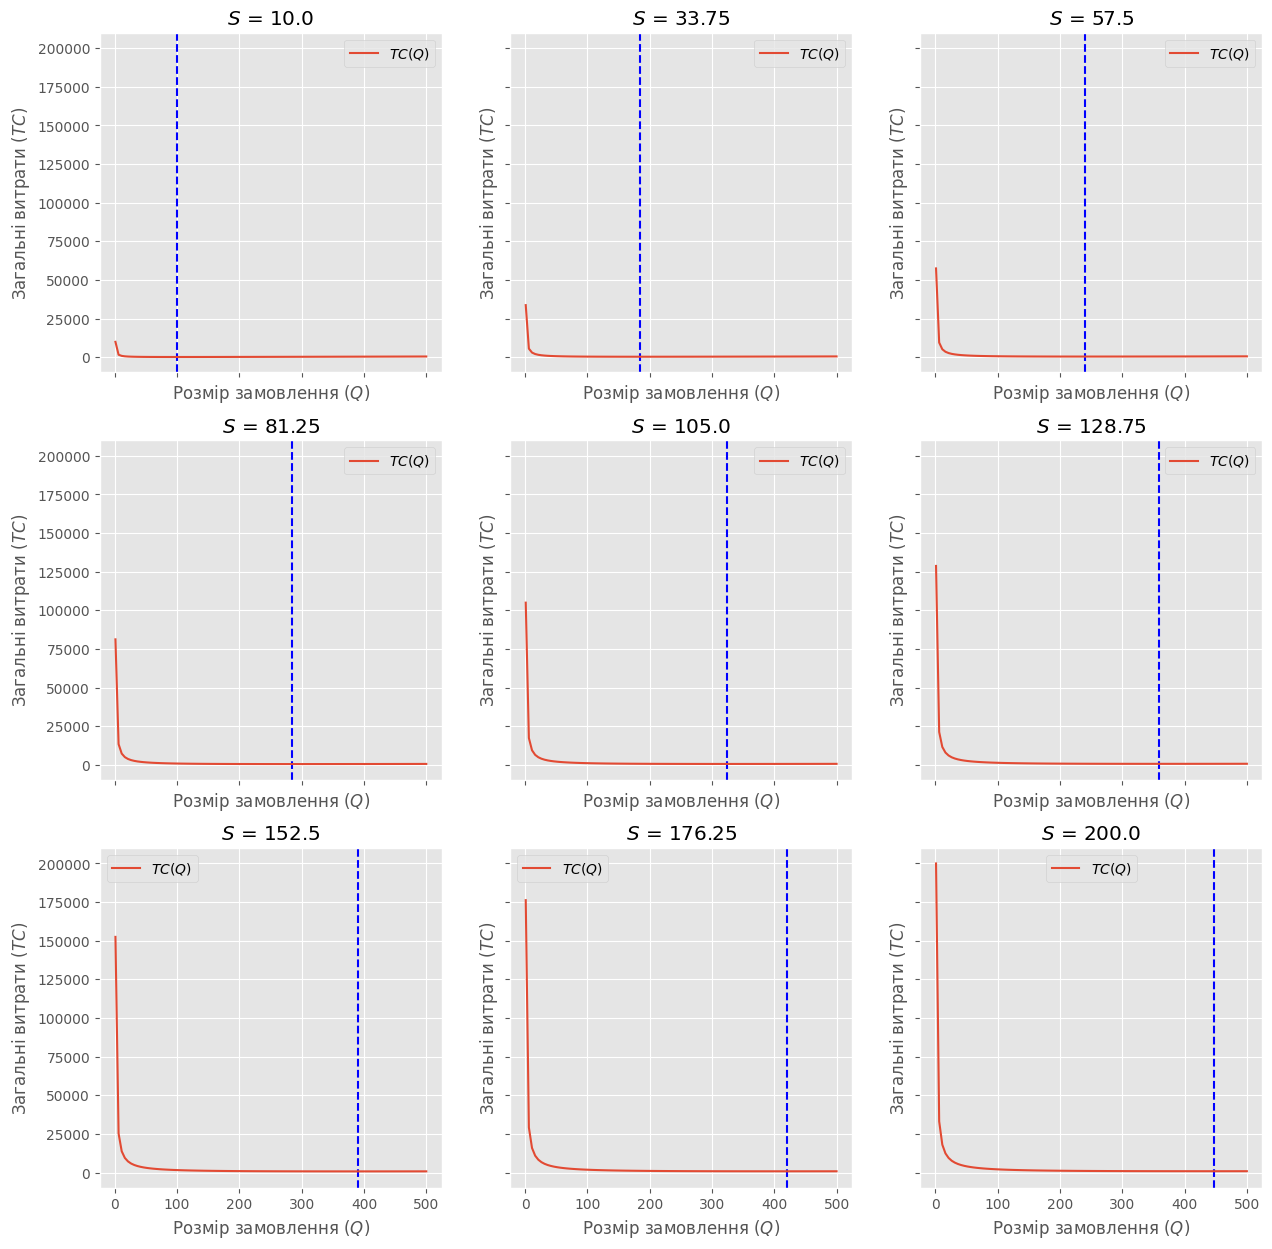

In [20]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

D = 1000
H = 2

for i in range(9):
    S = Ss[i]
    
    eoq = compute_eoq(D, S, H)
    axs[i//3][i%3].axvline(x=eoq, color="b", linestyle="--")
    axs[i//3][i%3].plot(q, total_cost(q, D, S, H), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$S$ = {S}")
    axs[i//3][i%3].set_xlabel(r"Розмір замовлення $(Q)$")
    axs[i//3][i%3].set_ylabel(r"Загальні витрати $(TC)$")

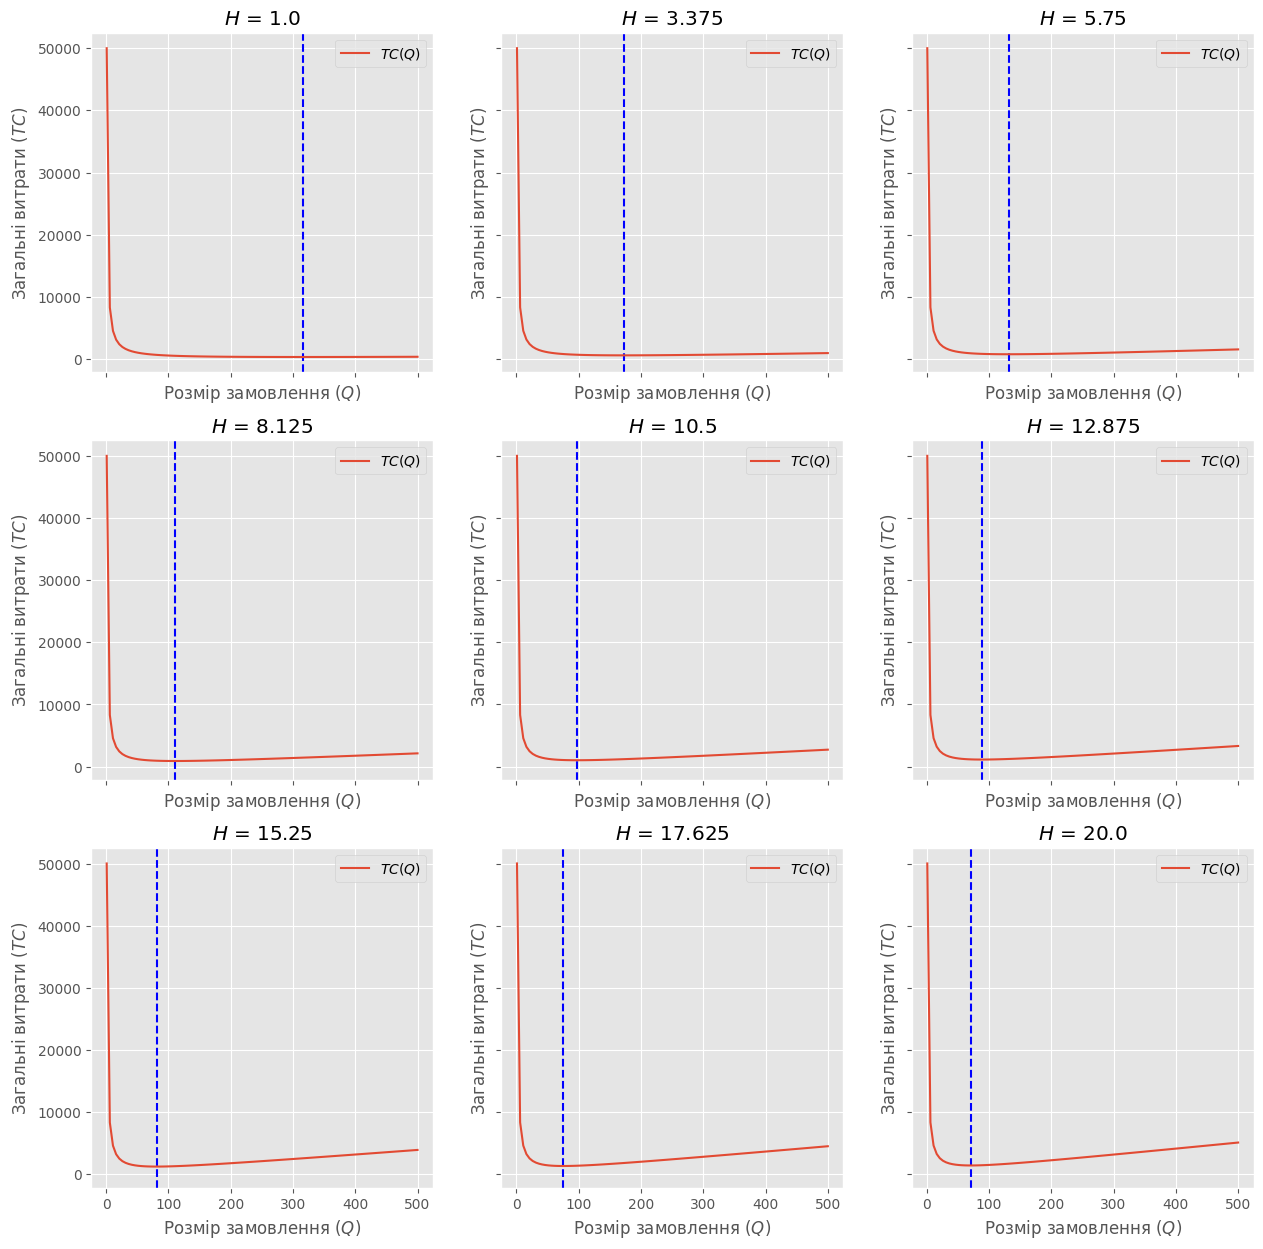

In [21]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

D = 1000
S = 50

for i in range(9):
    H = Hs[i]
    
    eoq = compute_eoq(D, S, H)
    axs[i//3][i%3].axvline(x=eoq, color="b", linestyle="--")
    axs[i//3][i%3].plot(q, total_cost(q, D, S, H), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$H$ = {H}")
    axs[i//3][i%3].set_xlabel(r"Розмір замовлення $(Q)$")
    axs[i//3][i%3].set_ylabel(r"Загальні витрати $(TC)$")

#### Модель попиту і пропозиції

$$
D(p) = a - b p,
$$
де
* $a$ — максимальний попит при нульовій ціні,
* $b$ — коеф. що визначає зниження попиту при зростанні ціни $p$.

$$
S(p) = c + d p,
$$
де
* $c$ — базова кількість товару, що пропонується при нульовій ціні,
* $d$ — коеф. що визначає зростання пропозиції при зростанні ціни $p$.

$$
\frac{dp}{dt} = \lambda \left( D(p) - S(p) \right),
$$
де $\lambda > 0$ — коеф. кореції ціни (швидкість адаптації).

In [22]:
def price(t: np.ndarray, p0: float, p_eq: float, lambda_coef: float, b: float, d: float) -> np.ndarray:
    return p_eq + (p0 - p_eq) * np.exp(-lambda_coef * (b + d) * t)

In [23]:
t = np.linspace(0, 50, 300)

a_s = np.linspace(100, 500, 9)
b_s = np.linspace(1, 5, 9)
c_s = np.linspace(10, 50, 9)
d_s = np.linspace(1, 5, 9)

lam_s = np.linspace(.01, .5, 9)

p0: float = 50

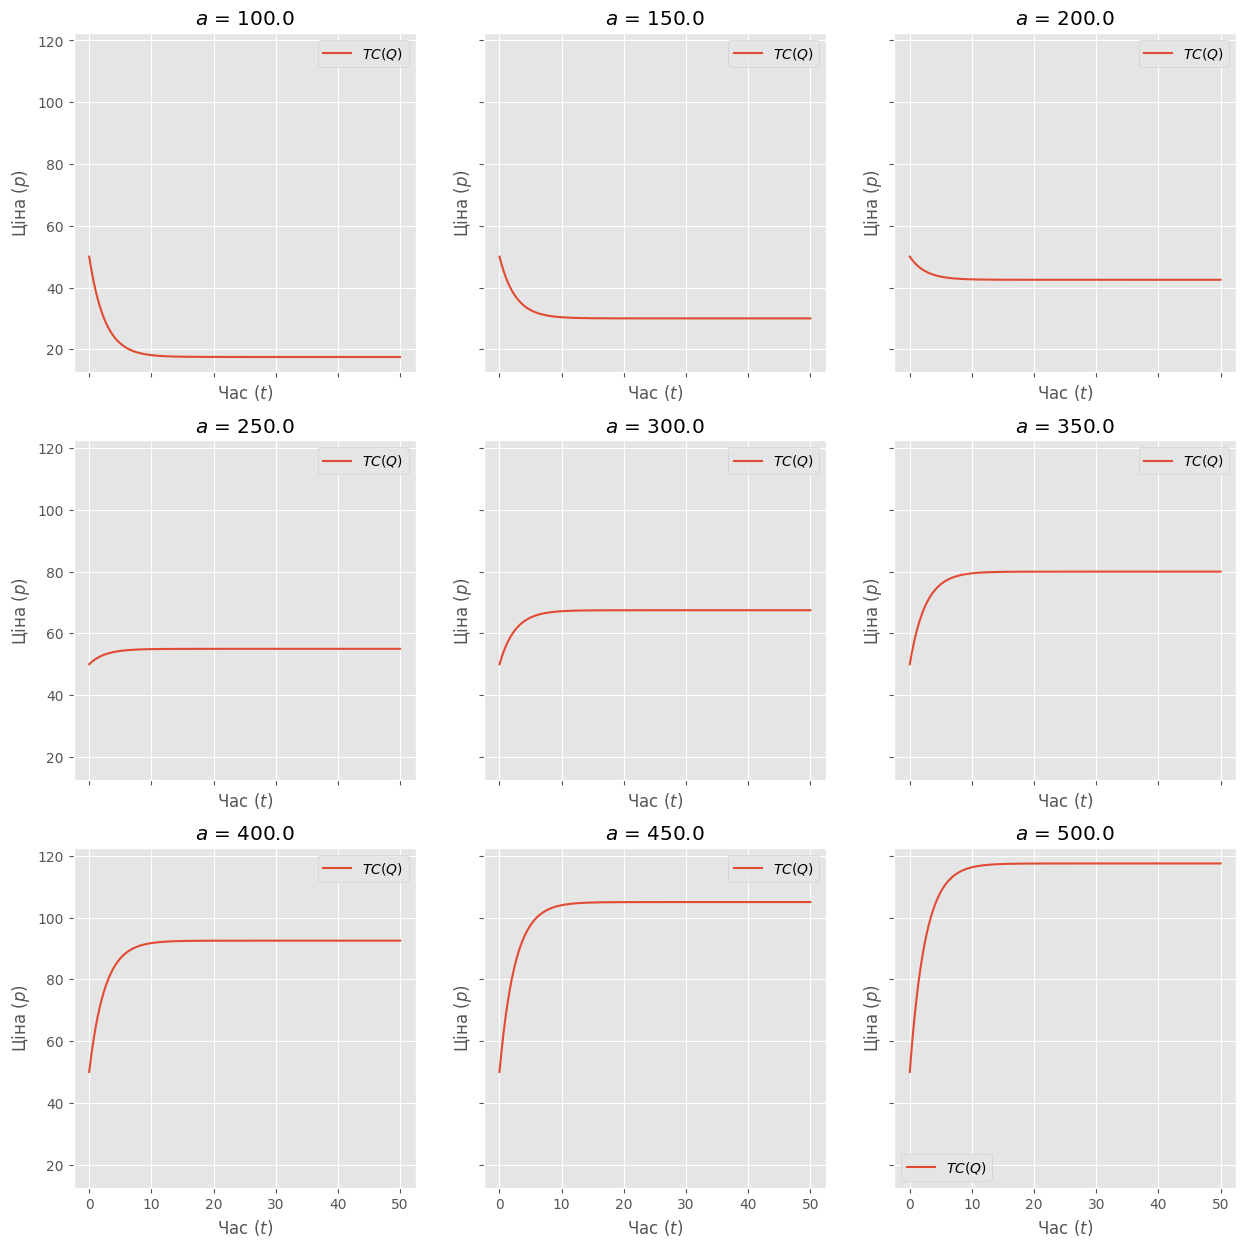

In [24]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

a = 300
b = 2.5
c = 30
d = 1.5
lam = .1

for i in range(9):
    a = a_s[i]
    
    p_eq: float = (a - c) / (b + d)
    axs[i//3][i%3].plot(t, price(t, p0, p_eq, lam, b, d), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$a$ = {a}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

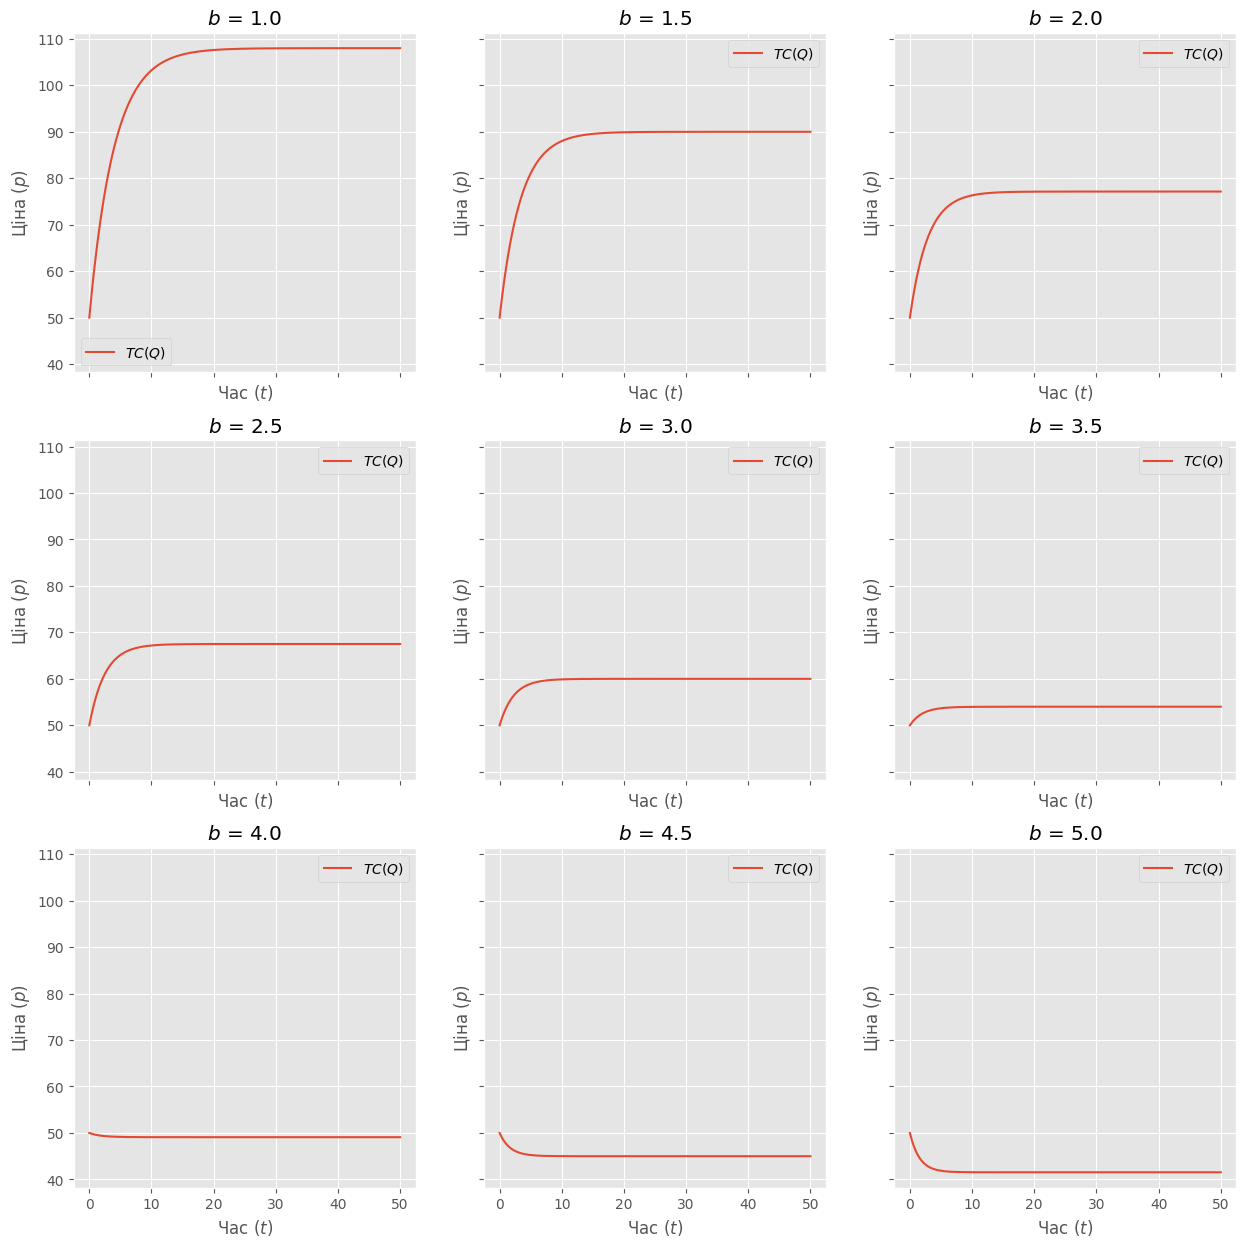

In [25]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

a = 300
b = 2.5
c = 30
d = 1.5
lam = .1

for i in range(9):
    b = b_s[i]
    
    p_eq: float = (a - c) / (b + d)
    axs[i//3][i%3].plot(t, price(t, p0, p_eq, lam, b, d), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$b$ = {b}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

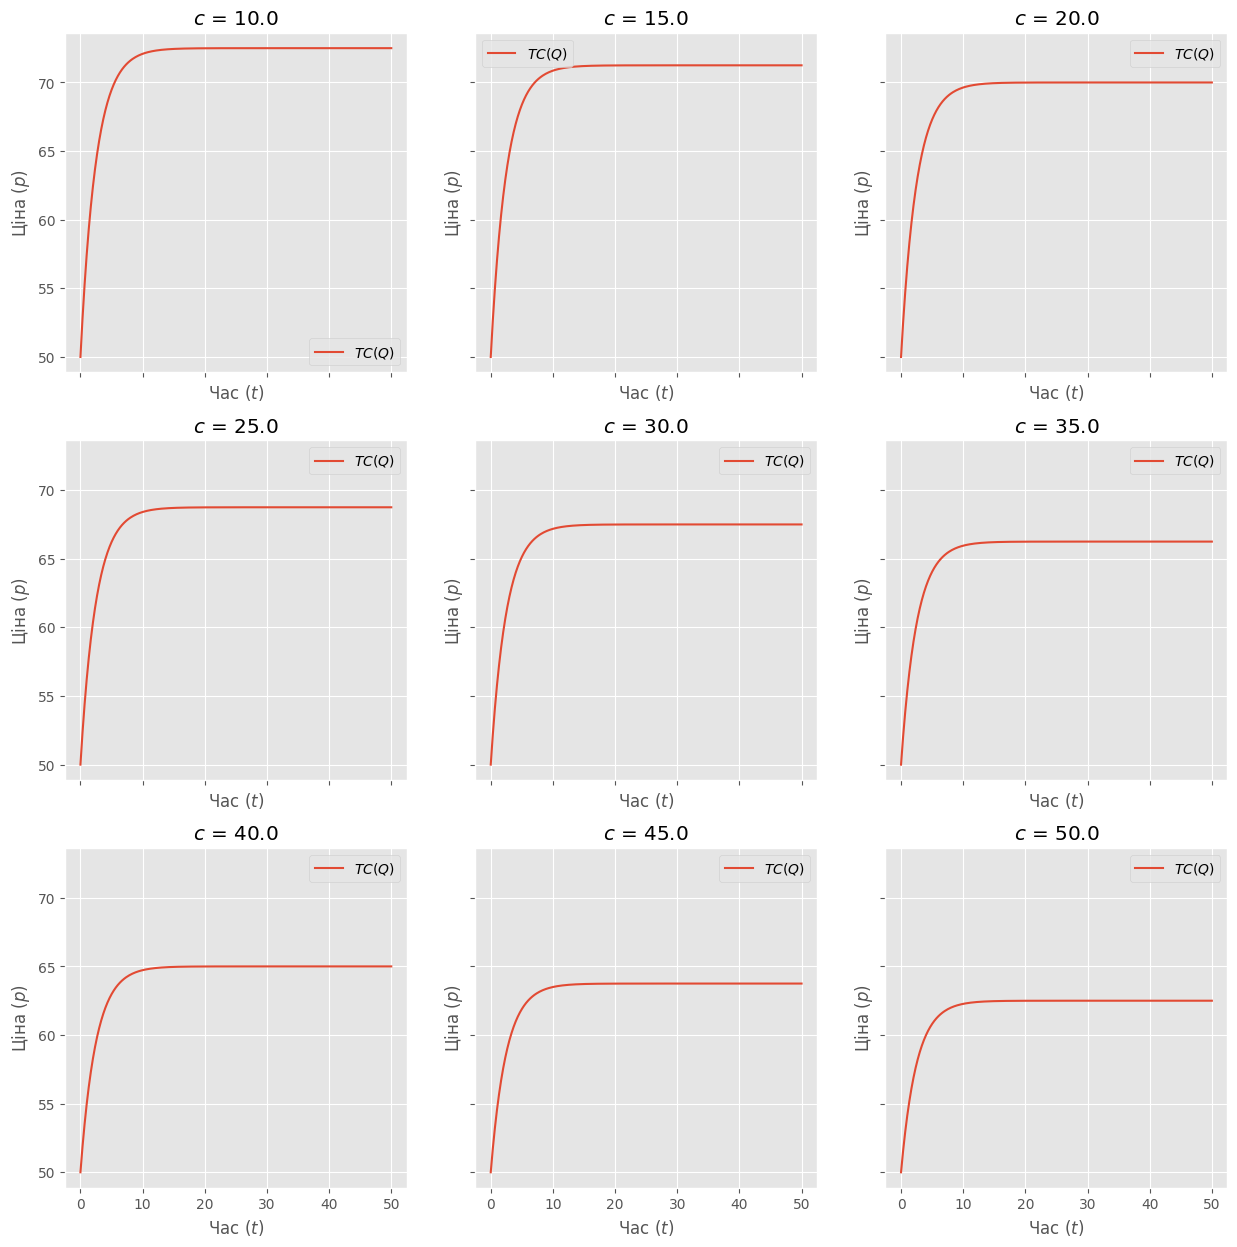

In [26]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

a = 300
b = 2.5
c = 30
d = 1.5
lam = .1

for i in range(9):
    c = c_s[i]
    
    p_eq: float = (a - c) / (b + d)
    axs[i//3][i%3].plot(t, price(t, p0, p_eq, lam, b, d), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$c$ = {c}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

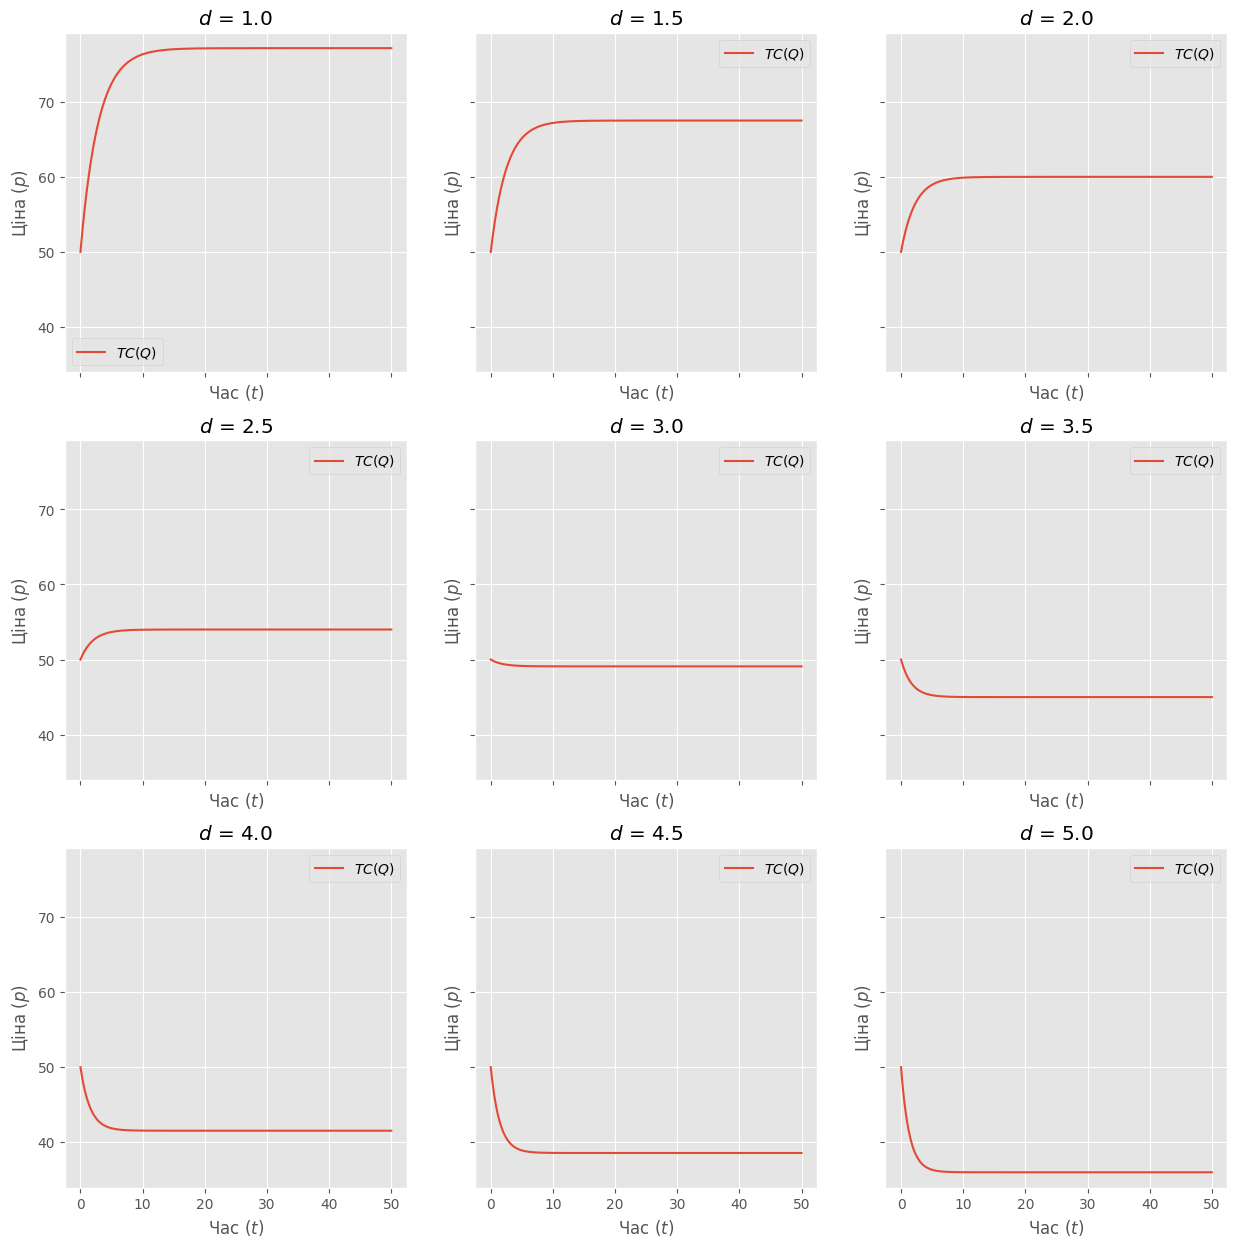

In [27]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

a = 300
b = 2.5
c = 30
d = 1.5
lam = .1

for i in range(9):
    d = d_s[i]
    
    p_eq: float = (a - c) / (b + d)
    axs[i//3][i%3].plot(t, price(t, p0, p_eq, lam, b, d), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$d$ = {d}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

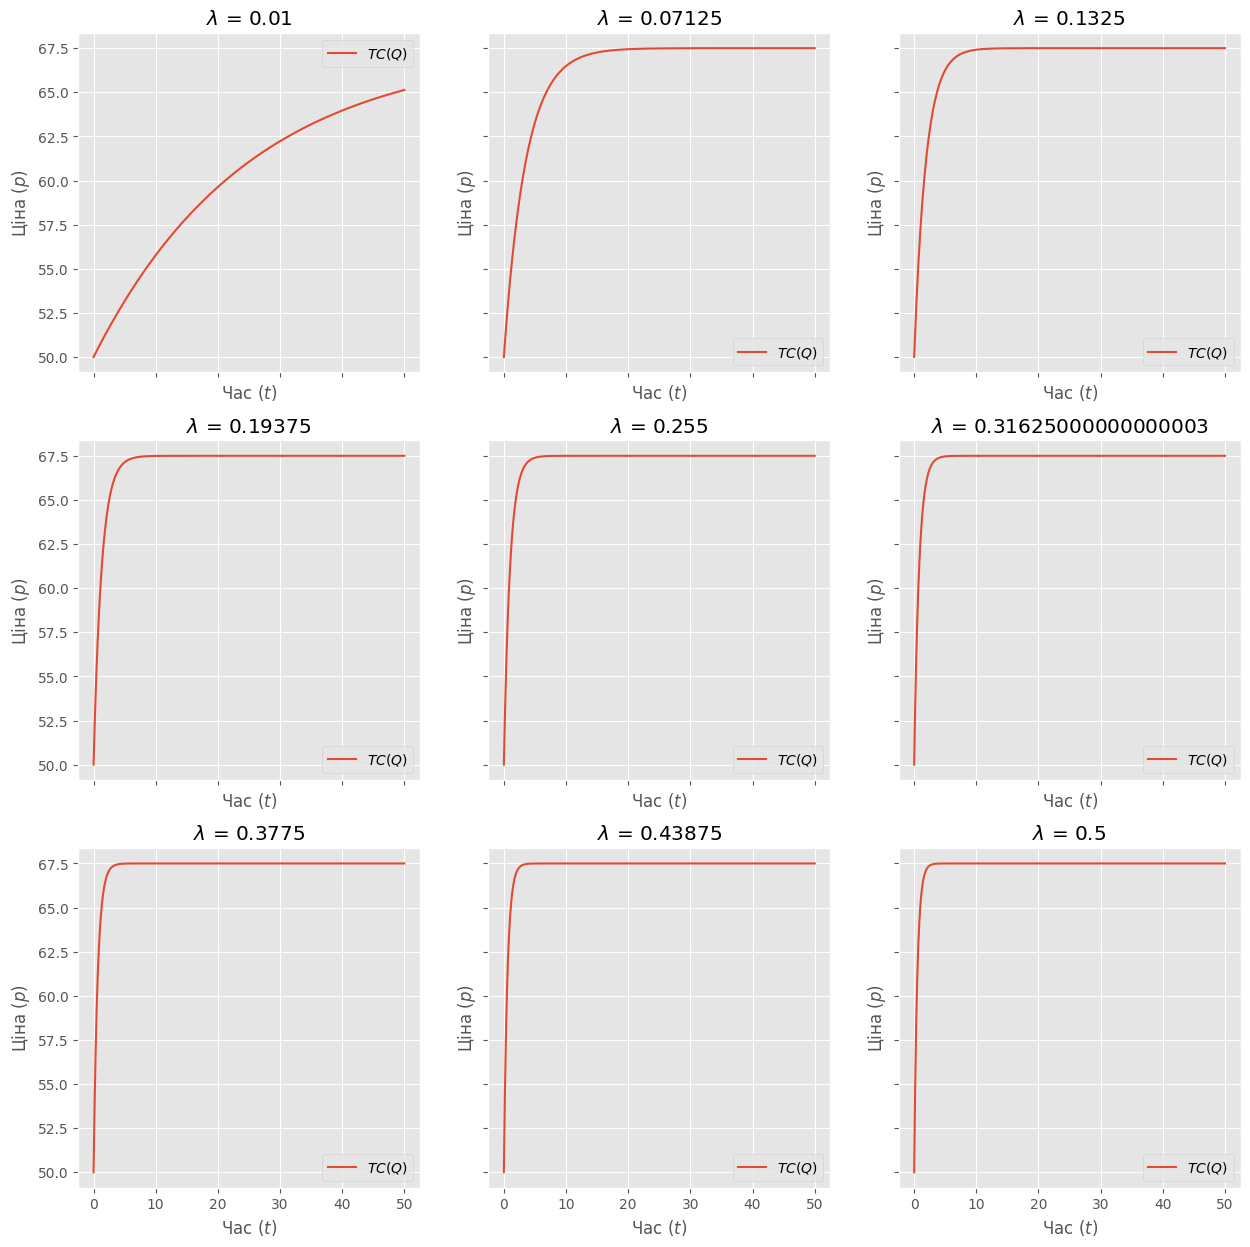

In [28]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

a = 300
b = 2.5
c = 30
d = 1.5
lam = .1

for i in range(9):
    lam = lam_s[i]
    
    p_eq: float = (a - c) / (b + d)
    axs[i//3][i%3].plot(t, price(t, p0, p_eq, lam, b, d), label=r"$TC(Q)$")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\lambda$ = {lam}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

#### Модель міграції

$$
\frac{dx}{dt} = -\mu x(t) + \nu y(t),
$$

$$
\frac{dy}{dt} = \mu x(t) - \nu y(t),
$$

де
* $\mu$ — втрата через міграцію,
* $\nu$ — поповнення через міграцію.

In [29]:
def migration_model(t: float, populations: np.ndarray) -> np.ndarray:
    x, y = populations
    dxdt: float = -mu * x + nu * y
    dydt: float = mu * x - nu * y
    return np.array([dxdt, dydt])

In [30]:
t = np.linspace(0, 100, 300)
x0 = 800
y0 = 200
N = x0 + y0

mu_s = np.linspace(.01, .2, 9)
nu_s = np.linspace(.01, .2, 9)

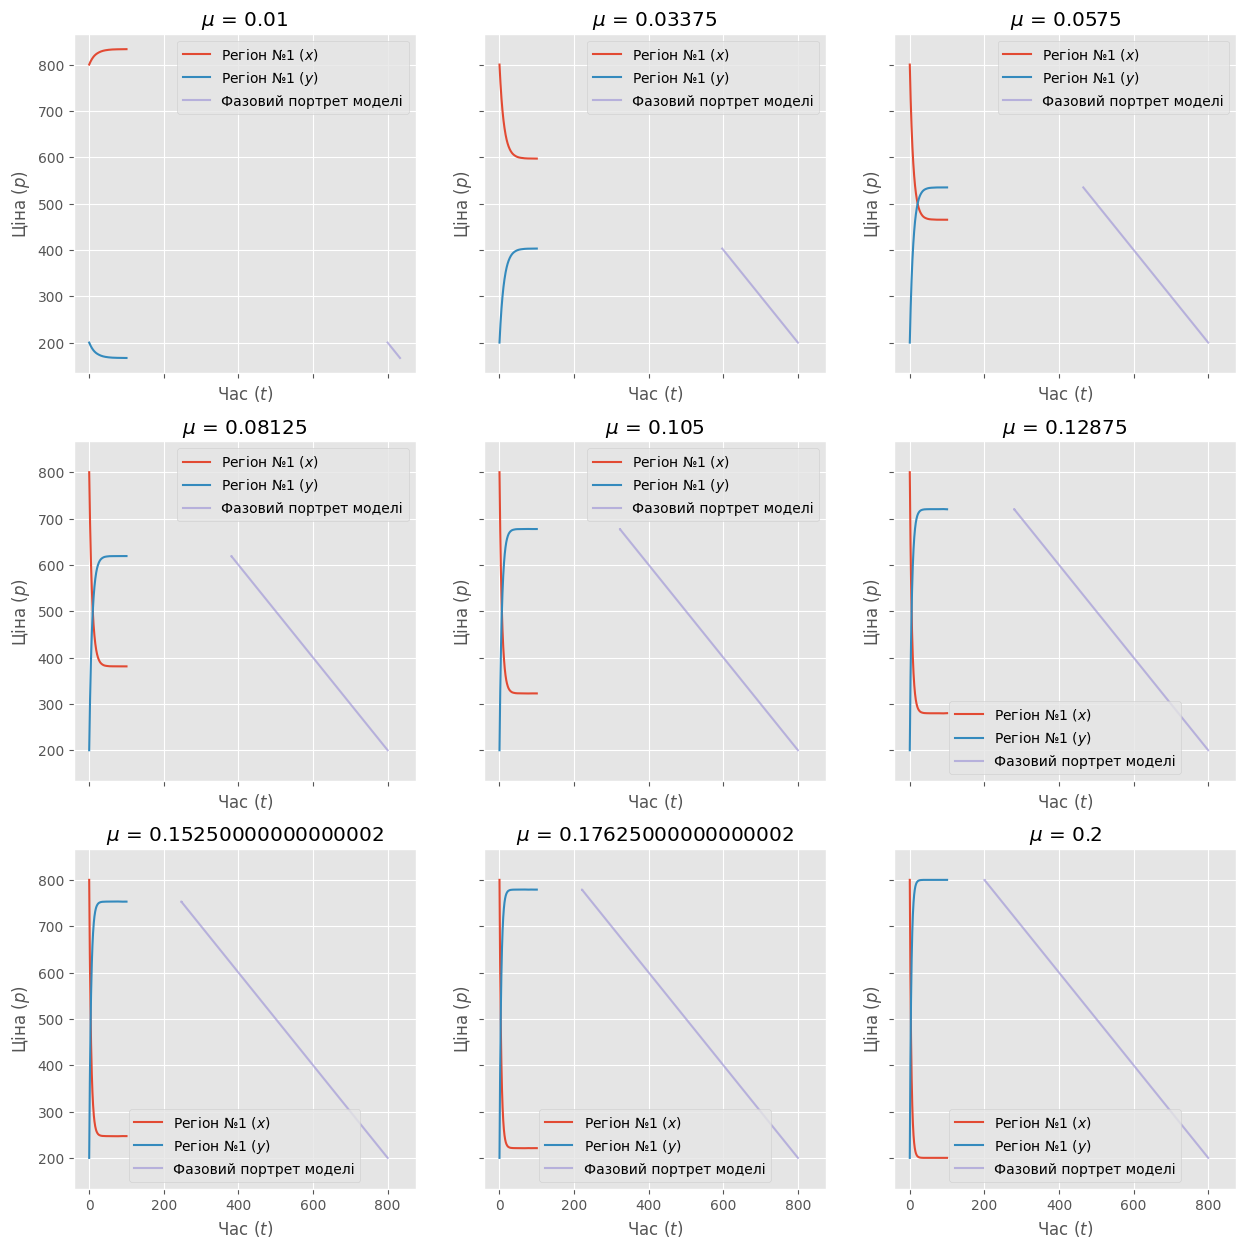

In [31]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

mu = .1
nu = .05

for i in range(9):
    mu = mu_s[i]
    
    solution = solve_ivp(migration_model, (0, 100), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label=r"Регіон №1 $(x)$")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label=r"Регіон №1 $(y)$")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], alpha=.6, label=r"Фазовий портрет моделі")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\mu$ = {mu}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

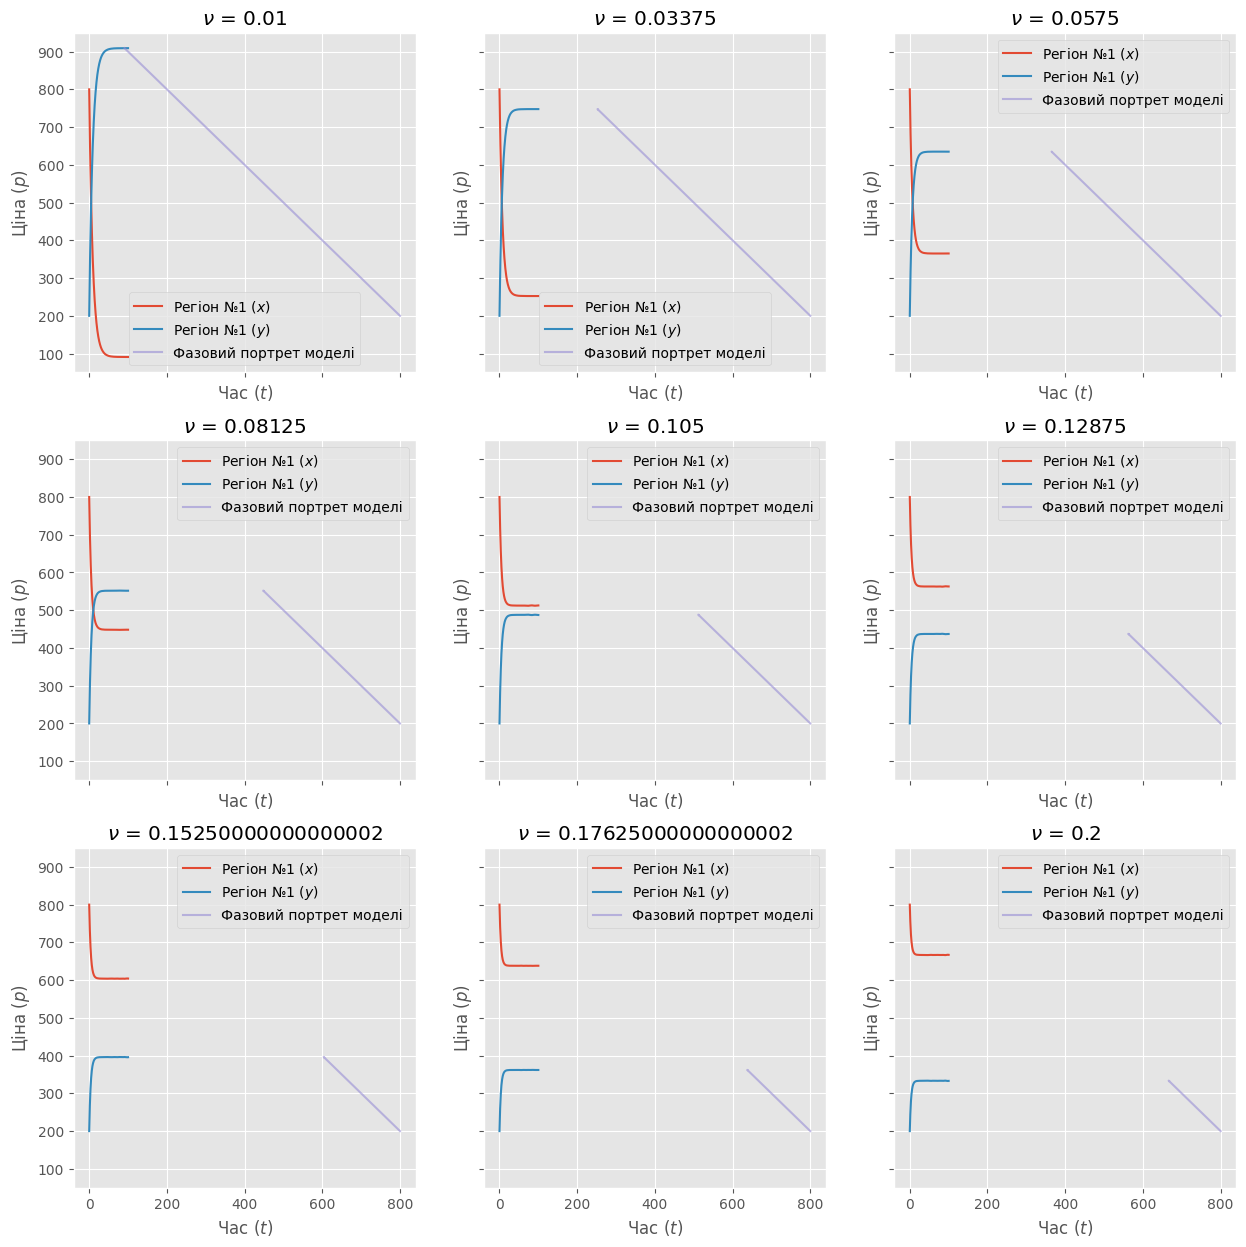

In [32]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

mu = .1
nu = .05

for i in range(9):
    nu = nu_s[i]
    
    solution = solve_ivp(migration_model, (0, 100), [x0, y0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label=r"Регіон №1 $(x)$")
    axs[i//3][i%3].plot(solution.t, solution.y[1], label=r"Регіон №1 $(y)$")
    axs[i//3][i%3].plot(solution.y[0], solution.y[1], alpha=.6, label=r"Фазовий портрет моделі")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\nu$ = {nu}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Ціна $(p)$")

#### Модель соціальної динаміки

$$
\frac{dx}{dt} = k x(1-x)(x-\theta),
$$
де

* $k>0$ — коеф. швидкості динаміки, який визначає, наскільки швидко відбуваються зміни;
* $\theta$ — критичний поріг (при $0<\theta<1$), який розділяє зони, де ідея або відкривається, або поширюється.

In [42]:
def social_dynamics(t: float, x: np.ndarray) -> np.ndarray:
    current_x: float = x[0]
    dxdt: float = k * current_x * (1 - current_x) * (current_x - theta)
    return np.array([dxdt])

In [57]:
t = np.linspace(0, 20, 300)
x0 = .4

k_s = np.linspace(.5, 2, 9)
theta_s = np.linspace(.2, .5, 9)

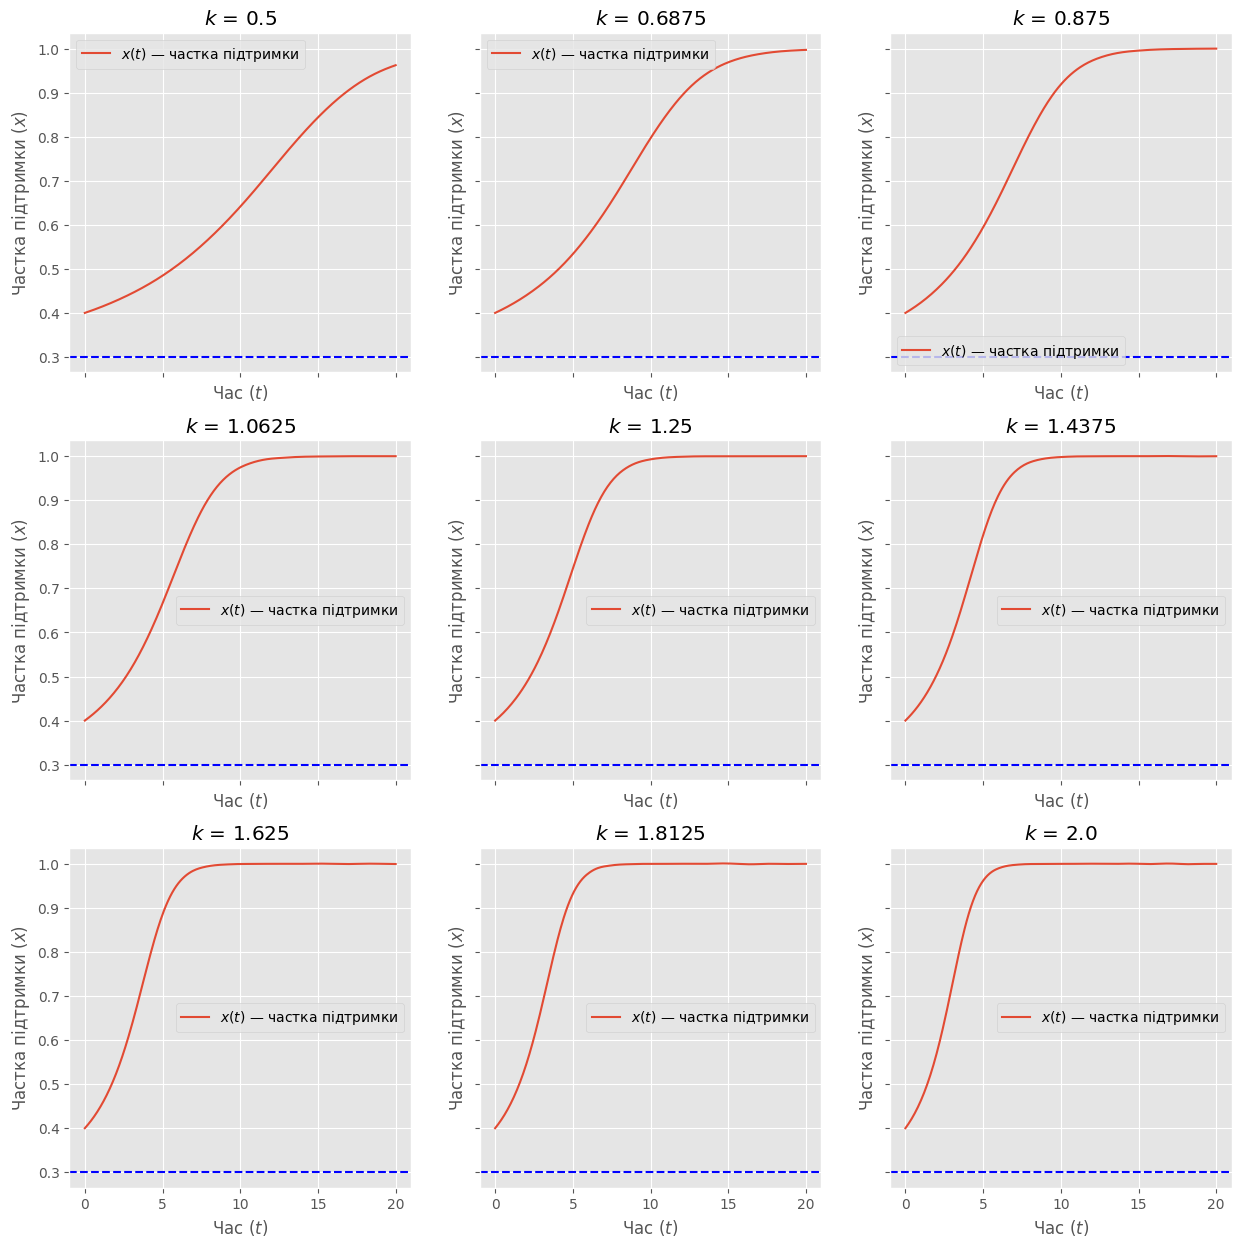

In [58]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

k = 1
theta = .3

for i in range(9):
    k = k_s[i]
    
    solution = solve_ivp(social_dynamics, (0, 20), [x0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label=r"$x(t)$ — частка підтримки")
    axs[i//3][i%3].axhline(y=theta, color="b", linestyle="--")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$k$ = {k}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Частка підтримки $(x)$")

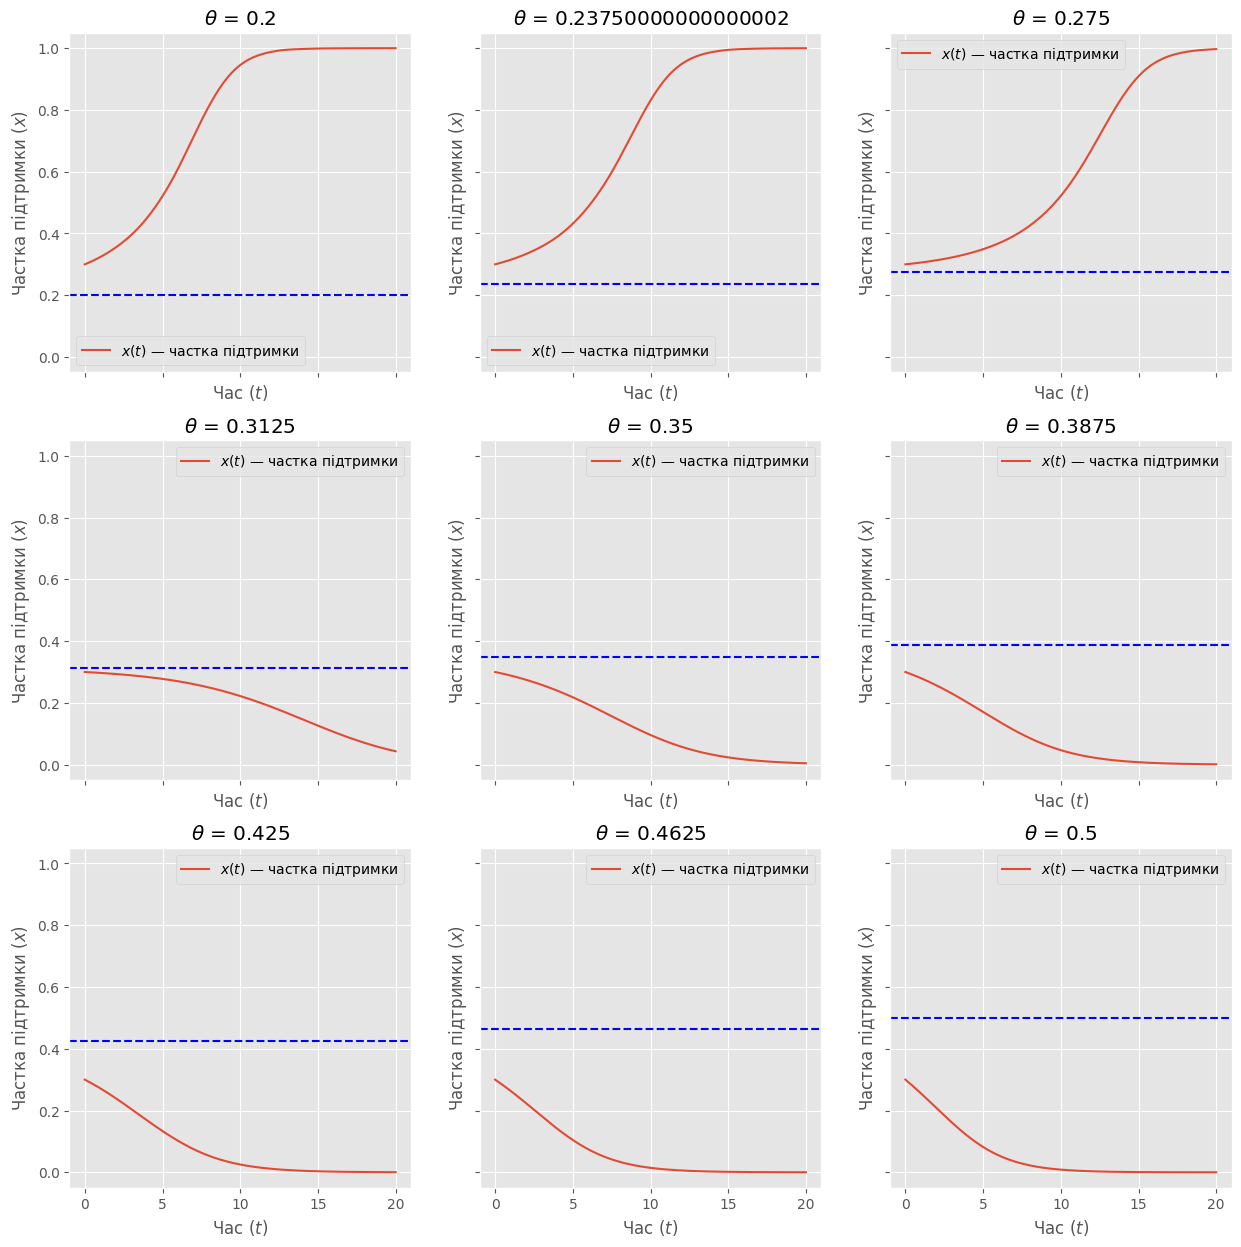

In [56]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15), sharex=True, sharey=True)

k = 1
theta = .3

for i in range(9):
    theta = theta_s[i]
    
    solution = solve_ivp(social_dynamics, (0, 20), [x0], t_eval=t)
    
    axs[i//3][i%3].plot(solution.t, solution.y[0], label=r"$x(t)$ — частка підтримки")
    axs[i//3][i%3].axhline(y=theta, color="b", linestyle="--")
    axs[i//3][i%3].legend()
    axs[i//3][i%3].set_title(fr"$\theta$ = {theta}")
    axs[i//3][i%3].set_xlabel(r"Час $(t)$")
    axs[i//3][i%3].set_ylabel(r"Частка підтримки $(x)$")

### Завдання №2
Додавання сезонності.

Модифікувати обрану модель (окрім моделі Мальтуса), додаючи сезонний компонент.

**Приклад:**
* *Для EOQ:*
Нехай щорічний попит $D$ стає функцією часу, наприклад,
$$
D(t) = D_0 \times \left( 1 + \sin \left(\frac{2\pi t}{T}\right) \right),
$$

де $T$ — період сезонності.
Проаналізувати, як сезонні коливання впливають на оптимальний розмір замовлення $Q^*$ та загальні витрати.

* *Для логістичної моделі:*
Нехай швидкість зростання $r$ залежить від сезону, наприклад,
$$
r = r_0 \times \left( 1 + 0.5 \times \sin \left( \frac{2\pi t}{T} \right) \right),
$$

де $T$ — період сезонності.

**Мета:**

Навчитися моделювати умови, коли зовнішні фактори (наприклад, сезонні коливаання) впливають на попит, пропозицію чи зростання популяції.

In [110]:
def migration_seasonal_dynamic(t, populations, mu0, nu, T_mu):
    x, y = populations
    # Додаємо коливання: mu(t) = mu0 * (1 + 0.5 * sin(...))
    # Це гарантує, що mu завжди > 0, але пульсує
    current_mu = mu0 * (1 + 0.9 * np.sin(2 * np.pi * t / T_mu))
    
    dxdt = -current_mu * x + nu * y
    dydt = current_mu * x - nu * y
    return [dxdt, dydt]

Text(0, 0.5, 'Регіон 2')

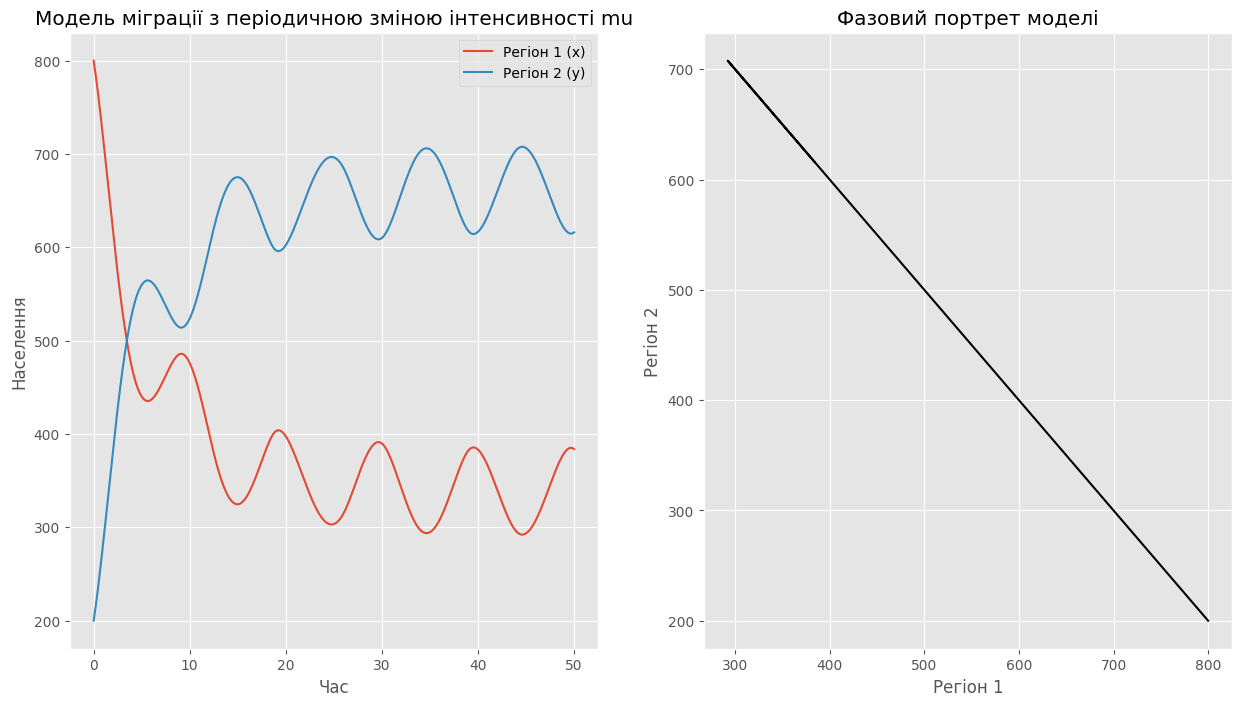

In [120]:
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
x0, y0 = 800, 200
mu0 = 0.1
nu = 0.05
T_mu = 10

sol = solve_ivp(
    migration_seasonal_dynamic, 
    t_span, 
    [x0, y0], 
    t_eval=t_eval, 
    args=(mu0, nu, T_mu)
)

fig, axs = plt.subplots(ncols=2, figsize=(15, 8))

axs[0].plot(sol.t, sol.y[0], label='Регіон 1 (x)')
axs[0].plot(sol.t, sol.y[1], label='Регіон 2 (y)')
axs[0].set_title('Модель міграції з періодичною зміною інтенсивності mu')
axs[0].set_xlabel('Час')
axs[0].set_ylabel('Населення')
axs[0].legend()

axs[1].plot(sol.y[0], sol.y[1], color="black")
axs[1].set_title('Фазовий портрет моделі')
axs[1].set_xlabel('Регіон 1')
axs[1].set_ylabel('Регіон 2')

### Додаткове завдання
Спробувати об'єднати декілька моделей для побудови більш комплексної системи, що відображає реальні бізнес-процеси.

**Приклад:**
Створіть інтегровану модель, яка поєднує модель прогнозування інвестицій з моделлю попиту і пропозиції. Наприклад, додайте сезонний фактор до прогнозування інвестицій, що впливає на виробництво і, відповідно, на попит і пропозицію продукту.

**Мета:**

Розвинути навички створення комлексних моделей, які враховують взаємозв'язок між різними бізнес-процесами.

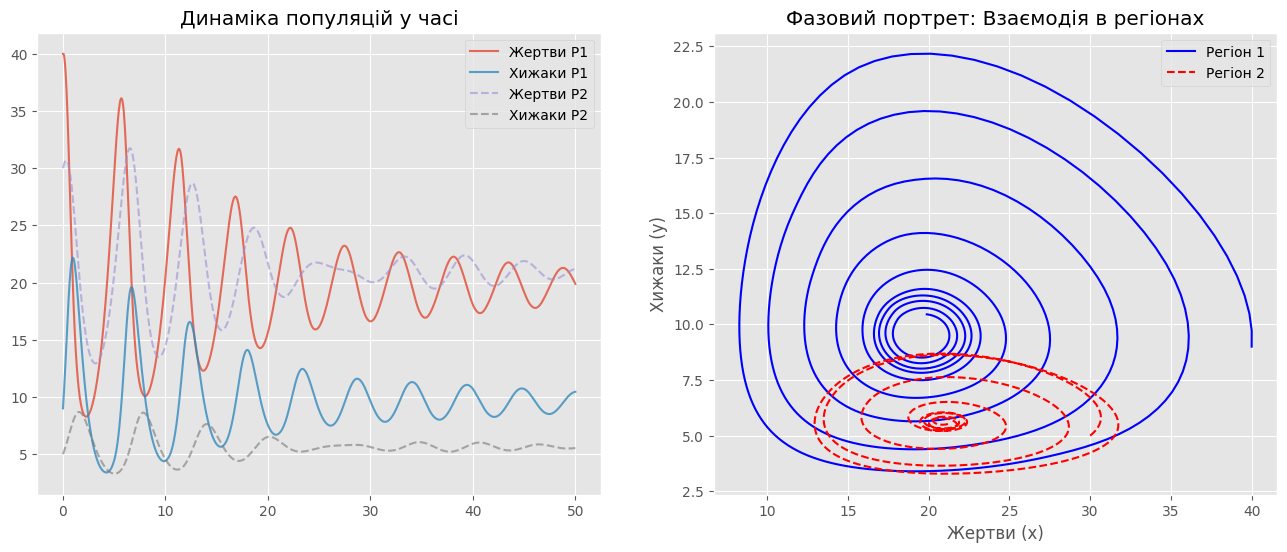

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def complex_migration_lv(t, state, a1, b1, d1, g1, a2, b2, d2, g2, m_x, n_x, m_y, n_y):
    x1, y1, x2, y2 = state
    
    # Регіон 1: Локальна динаміка + міграція
    dx1dt = (a1 * x1 - b1 * x1 * y1) + (n_x * x2 - m_x * x1)
    dy1dt = (d1 * x1 * y1 - g1 * y1) + (n_y * y2 - m_y * y1)
    
    # Регіон 2: Локальна динаміка + міграція
    dx2dt = (a2 * x2 - b2 * x2 * y2) + (m_x * x1 - n_x * x2)
    dy2dt = (d2 * x2 * y2 - g2 * y2) + (m_y * y1 - n_y * y2)
    
    return [dx1dt, dy1dt, dx2dt, dy2dt]

# Параметри (можна взяти з лекції та адаптувати)
params = (1.0, 0.1, 0.075, 1.5,  # Регіон 1 (alpha, beta, delta, gamma)
          0.8, 0.15, 0.05, 1.0,  # Регіон 2 (інші умови)
          0.1, 0.05,             # Міграція жертв (mu_x, nu_x)
          0.02, 0.08)            # Міграція хижаків (mu_y, nu_y)

t_eval = np.linspace(0, 50, 1000)
sol = solve_ivp(complex_migration_lv, (0, 50), [40, 9, 30, 5], t_eval=t_eval, args=params)

# Візуалізація
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Лівий графік: Динаміка в часі
axs[0].plot(sol.t, sol.y[0], label='Жертви Р1', alpha=0.8)
axs[0].plot(sol.t, sol.y[1], label='Хижаки Р1', alpha=0.8)
axs[0].plot(sol.t, sol.y[2], '--', label='Жертви Р2', alpha=0.6)
axs[0].plot(sol.t, sol.y[3], '--', label='Хижаки Р2', alpha=0.6)
axs[0].set_title('Динаміка популяцій у часі')
axs[0].legend()
axs[0].grid(True)

# Правий графік: Фазовий портрет (Хижак vs Жертва)
axs[1].plot(sol.y[0], sol.y[1], label='Регіон 1', color='blue')
axs[1].plot(sol.y[2], sol.y[3], label='Регіон 2', color='red', linestyle='--')
axs[1].set_xlabel('Жертви (x)')
axs[1].set_ylabel('Хижаки (y)')
axs[1].set_title('Фазовий портрет: Взаємодія в регіонах')
axs[1].legend()
axs[1].grid(True)